<a href="https://colab.research.google.com/github/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/nb1_scientific_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 직접 만드는 "Claude Code식" 과학 에이전트 — 신약개발 자율 파이프라인

**6일차 실습 · 대규모 언어모델과 신약개발 (2026)**

이 노트북은 LLM 에이전트를 **처음부터** 만들어 본다. 챗봇이 아니라 **도구(tool)를 실행하는 워커**로서,
자연어 목표 하나("EGFR 저해제 후보를 조사하고 약물성을 평가하라")를 받아
**타겟 조사 → 후보 검색 → ADMET 평가 → 보고서 작성**까지 스스로 수행한다.

## 0. 실행 환경

**완전 무료.** Colab에서는 `rdkit`, `requests` 만 있으면 무-키(no API key) 경로로 전체가 돌아간다 (0원).
사용하는 데이터 도구는 전부 **무료 공개 API/오픈소스**다: PubMed(NCBI E-utilities), UniProt REST, ChEMBL REST, RDKit.
진짜 LLM 추론을 무료로 보고 싶으면 **Gemini 무료 티어** 키(`GOOGLE_API_KEY`)만 넣으면 된다(아래 4절).

아래 셀이 필요한 패키지를 먼저 확인해 **없는 것만** 설치하고, 연산 장치를 `DEVICE` 상수 하나로 고정한다.
LLM 클라이언트(`google-genai` / `anthropic` / `openai`)는 **키가 있을 때만** 4절에서 지연 설치되므로
여기서는 설치하지 않는다. 7-3절의 `scikit-learn` 도 마찬가지로 그 자리에서 확인한다.

In [1]:
import importlib, subprocess, sys

REQUIRED = {
    # "import 이름": "pip 패키지명"
    "rdkit": "rdkit",          # SMILES 파싱 · 물성 계산 · 2D 구조 그림
    "requests": "requests",    # 공개 REST API 호출 (PubMed / UniProt / ChEMBL / PubChem)
}

def ensure(packages: dict) -> list:
    """import 가능한지 먼저 확인하고, 없는 것만 pip로 설치한다."""
    missing = [pip_name for mod, pip_name in packages.items()
               if importlib.util.find_spec(mod) is None]
    if missing:
        print("설치 대상:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    else:
        print("모든 의존 패키지가 이미 준비되어 있습니다.")
    return missing

ensure(REQUIRED)


import json, time, textwrap, os
import requests
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, QED, Lipinski, Crippen, rdMolDescriptors

# 연산 장치는 이 상수 하나로 고정한다 (6일차 다른 노트북과 동일한 표기).
# 이 노트북의 계산은 전부 공개 API 호출과 RDKit(CPU) 이라 GPU 유무로 결과가 달라지지 않는다.
if importlib.util.find_spec("torch") is not None:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
else:
    DEVICE = "cpu"

print("rdkit", Chem.rdBase.rdkitVersion, "| requests", requests.__version__)
print("DEVICE =", DEVICE)
if DEVICE == "cpu":
    print("[안내] CPU 경로입니다. 이 노트북은 GPU 연산을 쓰지 않으므로 결과와 속도가 동일합니다.")
else:
    print("[안내] GPU가 감지됐지만 이 노트북의 도구(REST API + RDKit)는 GPU를 사용하지 않습니다.")

# 공용 HTTP 헤더 (NCBI 등은 UA/연락처 권장). 이메일은 필요 시 수정.
UA = {"User-Agent": "lecture-scientific-agent/1.0 (mailto:student@example.com)"}


모든 의존 패키지가 이미 준비되어 있습니다.


rdkit 2026.03.5 | requests 2.34.2
DEVICE = cpu
[안내] CPU 경로입니다. 이 노트북은 GPU 연산을 쓰지 않으므로 결과와 속도가 동일합니다.


In [2]:
# --- 0-2. 그림 공통 설정 (6일차 다른 노트북과 동일한 폰트/팔레트/해상도) ---
ensure({"matplotlib": "matplotlib", "networkx": "networkx"})

import matplotlib as mpl
import matplotlib.pyplot as plt

# Colab 기본 폰트에는 한글 글리프가 없다. 폰트를 설치하는 대신
# '그림 라벨은 영어, 해석은 print() 한글' 규약을 쓴다 (다른 노트북과 동일).
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 120,          # 화면용. 저장 시에는 savefig(dpi=300) 을 따로 준다.
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Okabe-Ito: 적록색약에서도 구분되는 팔레트 (이 노트북의 모든 그림이 이 색만 쓴다)
CB = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73", "red": "#D55E00",
      "purple": "#CC79A7", "sky": "#56B4E9", "yellow": "#F0E442", "grey": "#999999"}

def _nodata(ax, msg):
    """데이터가 없으면 빈 축에 사유만 적는다 (없는 값을 그려 넣지 않기 위함)."""
    ax.text(0.5, 0.5, msg, ha="center", va="center", fontsize=11,
            color=CB["grey"], transform=ax.transAxes, wrap=True)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

print("그림 설정 완료 — DejaVu Sans, Okabe-Ito 색맹 안전 팔레트, 화면 120dpi / 저장 300dpi")
print("(그림 라벨이 영어인 이유: Colab 기본 폰트에 한글 글리프가 없어 깨지기 때문입니다.)")


모든 의존 패키지가 이미 준비되어 있습니다.


그림 설정 완료 — DejaVu Sans, Okabe-Ito 색맹 안전 팔레트, 화면 120dpi / 저장 300dpi
(그림 라벨이 영어인 이유: Colab 기본 폰트에 한글 글리프가 없어 깨지기 때문입니다.)


## 1. 개요와 학습 목표

1. **함수 호출(function calling)** 로 LLM에 도구를 등록하는 방법 — JSON schema 설계.
2. 신약개발 실무 도구 5종을 **실제 공개 API/실계산** 으로 구현: PubMed · UniProt · ChEMBL · RDKit 물성 · 규칙기반 ADMET.
3. **에이전트 루프(ReAct: Reason→Act→Observe)** 구조 — LLM이 어떤 도구를 언제 부를지 스스로 결정.
4. 엔드투엔드 자율 사이클을 돌리고, **구조 그림 + 보고서**를 자동 생성.
5. 에이전트 **고도화** — 도구 추가, 실패 디버깅(재시도/폴백), 안전(권한 최소화·키 격리·감사로그).
6. **장기 기억** — 구조화된 마크다운 위키(LLM-wiki 패턴)를 도구로 노출하고, **RAG와 성질 차이**를 직접 비교.

### 왜 지금(2026)인가 — "챗봇 → 워커"

2026년 프론티어 모델(Claude Opus 5/Sonnet 5, GPT-5.x, Gemini 3)의 핵심 흐름은 두 가지다:
(a) **추론(reasoning) 기본 탑재**, (b) **에이전틱(agentic) — 모델이 '대화 상대'에서 '도구를 실행하는 작업자'로**.
`Claude for Life Sciences`, `TxAgent/Agentic-Tx`, `Google AI co-scientist`, `PharmAgents`/`MADD`/`DiscoVerse`
같은 다중 에이전트 신약개발 시스템이 이 방향의 사례다. 이 노트북은 그 최소 골격을 손으로 만들어 본다.
(모델 버전은 빠르게 바뀜 — 2026.9 시점 확인 권장.)

> ⚠️ **무-날조(No-Fabrication) 원칙.** 이 노트북의 모든 수치·식별자(PMID, UniProt accession, ChEMBL ID,
> SMILES, 물성값)는 **실제 API 응답 또는 RDKit 실계산값** 이다. LLM이 IC50·ID·PMID를 지어내지 않는다.
> ADMET은 **규칙기반(Lipinski/Veber 등) 플래그**이며 ML "예측"이 아니다 — 마지막 한계 섹션 참고.

## 2. 도구(tool) 정의 — 에이전트의 "손과 발"

에이전트 = **LLM(두뇌) + 도구(손발) + 계획/검증**. LLM 혼자서는 최신 논문을 모르고, SMILES 물성을
계산하지 못하며, ChEMBL을 조회할 수 없다. 그래서 **실제로 실행되는 파이썬 함수**를 도구로 준다.

아래 5개 도구는 모두 **실데이터/실계산** 이다. 각 함수는
- 네트워크·파싱 오류에서 **죽지 않고** `{"error": ...}` 를 담은 구조화 결과를 반환하고(에이전트가 디버깅 가능),
- 성공 시 **출처(provenance)** 를 함께 반환한다(무-날조 감사용).

| 도구 | 데이터/계산 소스 | 반환 |
|------|------------------|------|
| `search_pubmed` | NCBI E-utilities (esearch+esummary) | 실제 PMID + 제목 + 저널/연도 |
| `lookup_uniprot` | UniProt REST | 실제 accession + 단백질명 + 서열 길이 |
| `search_chembl_actives` | ChEMBL REST | 실제 ChEMBL ID + canonical SMILES + pChEMBL |
| `mol_properties` | RDKit 실계산 | MW/logP/TPSA/HBD/HBA/QED |
| `admet_flags` | RDKit 기술자 + **규칙** | Lipinski/Veber/lead-like 위반 플래그 |

In [3]:
# ============================================================
# 도구 1: PubMed 검색 (NCBI E-utilities) — 실제 PMID/제목
# ============================================================
def search_pubmed(query: str, n: int = 5) -> dict:
    """PubMed에서 query로 상위 n편의 실제 논문(PMID/제목/저널/연도)을 반환."""
    base = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"
    try:
        r = requests.get(f"{base}/esearch.fcgi",
                         params={"db": "pubmed", "term": query, "retmax": n, "retmode": "json"},
                         headers=UA, timeout=20)
        r.raise_for_status()
        ids = r.json()["esearchresult"]["idlist"]
        if not ids:
            return {"query": query, "n": 0, "papers": [], "provenance": "NCBI PubMed E-utilities"}
        s = requests.get(f"{base}/esummary.fcgi",
                        params={"db": "pubmed", "id": ",".join(ids), "retmode": "json"},
                        headers=UA, timeout=20)
        s.raise_for_status()
        res = s.json()["result"]
        papers = []
        for pid in ids:
            d = res.get(pid, {})
            papers.append({
                "pmid": pid,
                "title": d.get("title", "").rstrip("."),
                "journal": d.get("fulljournalname") or d.get("source", ""),
                "year": (d.get("pubdate", "") or "")[:4],
            })
        return {"query": query, "n": len(papers), "papers": papers,
                "provenance": "NCBI PubMed E-utilities (esearch+esummary)"}
    except Exception as e:
        return {"query": query, "error": f"{type(e).__name__}: {e}",
                "provenance": "NCBI PubMed (request failed)"}


# ============================================================
# 도구 2: UniProt 조회 — 유전자명 또는 accession → 실제 단백질 정보
# ============================================================
def lookup_uniprot(gene_or_id: str, organism_id: int = 9606) -> dict:
    """UniProt에서 유전자명/accession으로 리뷰된(Swiss-Prot) 단백질 1건을 조회."""
    base = "https://rest.uniprot.org/uniprotkb"
    try:
        token = gene_or_id.strip()
        # accession 형식(예: P00533)이면 직접, 아니면 gene 검색
        if len(token) <= 10 and token[0].isalpha() and any(c.isdigit() for c in token) and " " not in token:
            r = requests.get(f"{base}/{token}.json", headers=UA, timeout=25)
            if r.status_code == 200:
                d = r.json()
            else:
                d = None
        else:
            d = None
        if d is None:
            q = f"gene:{token} AND organism_id:{organism_id} AND reviewed:true"
            r = requests.get(f"{base}/search",
                            params={"query": q, "format": "json", "size": 1}, headers=UA, timeout=25)
            r.raise_for_status()
            hits = r.json().get("results", [])
            if not hits:
                return {"query": gene_or_id, "error": "no reviewed entry found",
                        "provenance": "UniProt REST"}
            d = hits[0]
        name = (d.get("proteinDescription", {}).get("recommendedName", {})
                 .get("fullName", {}).get("value", ""))
        gene = ""
        if d.get("genes"):
            gene = d["genes"][0].get("geneName", {}).get("value", "")
        func = ""
        for c in d.get("comments", []):
            if c.get("commentType") == "FUNCTION" and c.get("texts"):
                func = c["texts"][0].get("value", ""); break
        return {
            "query": gene_or_id,
            "accession": d.get("primaryAccession"),
            "gene": gene,
            "protein": name,
            "length": d.get("sequence", {}).get("length"),
            "function": func[:400],
            "provenance": f"UniProt REST ({d.get('primaryAccession')})",
        }
    except Exception as e:
        return {"query": gene_or_id, "error": f"{type(e).__name__}: {e}",
                "provenance": "UniProt REST (request failed)"}


# ============================================================
# 도구 3: ChEMBL 활성물질 — 타겟명 → 실제 활성 화합물(ID+SMILES+pChEMBL)
# ============================================================
def search_chembl_actives(target: str, n: int = 8) -> dict:
    """타겟명(예: 'EGFR')으로 ChEMBL 단백질 타겟을 찾고, IC50 활성 화합물을 반환."""
    base = "https://www.ebi.ac.uk/chembl/api/data"
    try:
        r = requests.get(f"{base}/target/search",
                        params={"q": target, "format": "json"}, headers=UA, timeout=25)
        r.raise_for_status()
        tgts = r.json().get("targets", [])
        if not tgts:
            return {"target": target, "error": "no ChEMBL target", "provenance": "ChEMBL REST"}
        human = [t for t in tgts if t.get("organism") == "Homo sapiens"
                 and t.get("target_type") == "SINGLE PROTEIN"]
        tgt = (human or tgts)[0]
        tid = tgt["target_chembl_id"]
        a = requests.get(f"{base}/activity",
                        params={"target_chembl_id": tid, "standard_type": "IC50",
                                "pchembl_value__isnull": "false",
                                "limit": max(n * 6, 40), "format": "json"},
                        headers=UA, timeout=35)
        a.raise_for_status()
        seen, rows = set(), []
        for act in a.json().get("activities", []):
            mid = act.get("molecule_chembl_id"); smi = act.get("canonical_smiles")
            if not mid or not smi or mid in seen:
                continue
            if Chem.MolFromSmiles(smi) is None:   # 무-날조: 파싱 안 되면 버림
                continue
            seen.add(mid)
            rows.append({"molecule_chembl_id": mid, "canonical_smiles": smi,
                         "pchembl_value": act.get("pchembl_value"),
                         "standard_value": act.get("standard_value"),
                         "standard_units": act.get("standard_units")})
            if len(rows) >= n:
                break
        return {"target": target, "target_chembl_id": tid,
                "target_pref_name": tgt.get("pref_name"), "n": len(rows), "actives": rows,
                "provenance": f"ChEMBL REST (target {tid}, IC50, pChEMBL not null)"}
    except Exception as e:
        return {"target": target, "error": f"{type(e).__name__}: {e}",
                "provenance": "ChEMBL REST (request failed)"}


# ============================================================
# 도구 4: RDKit 물성 (실계산)
# ============================================================
def mol_properties(smiles: str) -> dict:
    """SMILES의 물리화학 물성을 RDKit로 실제 계산."""
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return {"smiles": smiles, "error": "invalid SMILES (RDKit parse failed)"}
    return {
        "smiles": smiles,
        "MW": round(Descriptors.MolWt(m), 1),
        "logP": round(Crippen.MolLogP(m), 2),
        "TPSA": round(rdMolDescriptors.CalcTPSA(m), 1),
        "HBD": Lipinski.NumHDonors(m),
        "HBA": Lipinski.NumHAcceptors(m),
        "RotB": Lipinski.NumRotatableBonds(m),
        "QED": round(QED.qed(m), 3),
        "provenance": "RDKit Descriptors/QED (real computation)",
    }


# ============================================================
# 도구 5: 규칙기반 ADMET 플래그 (ML 예측 아님 — 규칙!)
# ============================================================
def admet_flags(smiles: str) -> dict:
    """RDKit 기술자에 Lipinski Ro5 / Veber / lead-like 규칙을 적용해 위반 플래그를 반환.
    주의: 이는 **규칙기반 필터**이며 흡수/독성 ML '예측'이 아니다."""
    p = mol_properties(smiles)
    if "error" in p:
        return p
    mw, logp, hbd, hba, tpsa, rotb = p["MW"], p["logP"], p["HBD"], p["HBA"], p["TPSA"], p["RotB"]
    ro5 = {"MW<=500": mw <= 500, "logP<=5": logp <= 5, "HBD<=5": hbd <= 5, "HBA<=10": hba <= 10}
    ro5_viol = sum(1 for v in ro5.values() if not v)
    veber = {"RotB<=10": rotb <= 10, "TPSA<=140": tpsa <= 140}
    veber_viol = sum(1 for v in veber.values() if not v)
    leadlike = {"MW<=350": mw <= 350, "logP<=3.5": logp <= 3.5}
    return {
        "smiles": smiles,
        "lipinski_ro5": {"violations": ro5_viol, "pass": ro5_viol <= 1, "detail": ro5},
        "veber": {"violations": veber_viol, "pass": veber_viol == 0, "detail": veber},
        "lead_like": {"pass": all(leadlike.values()), "detail": leadlike},
        "note": "규칙기반(rule-based) 필터 — ADMET ML 예측이 아님. 실검증 별도.",
        "provenance": "RDKit descriptors + Lipinski/Veber/lead-like rules",
    }

print("도구 5종 정의 완료: search_pubmed, lookup_uniprot, search_chembl_actives, mol_properties, admet_flags")


도구 5종 정의 완료: search_pubmed, lookup_uniprot, search_chembl_actives, mol_properties, admet_flags


### 2-1. 도구 스모크 테스트 — 실데이터가 나오는지 즉시 확인
에이전트에 넘기기 전에 각 도구가 **실제 값**을 반환하는지 눈으로 확인한다. (무-날조 검증)

In [4]:
demo_target = "EGFR"

pm = search_pubmed(f"{demo_target} inhibitor drug discovery", n=3)
print("● PubMed:", pm.get("n"), "papers")
for p in pm.get("papers", []):
    print(f"   PMID {p['pmid']} ({p['year']}) {p['title'][:70]}")

up = lookup_uniprot(demo_target)
print("\n● UniProt:", up.get("accession"), "|", up.get("protein"), "| len", up.get("length"))

ch = search_chembl_actives(demo_target, n=5)
print("\n● ChEMBL target:", ch.get("target_chembl_id"), ch.get("target_pref_name"), "| actives:", ch.get("n"))
for a in ch.get("actives", [])[:3]:
    print(f"   {a['molecule_chembl_id']}  pChEMBL={a['pchembl_value']}  {a['canonical_smiles'][:45]}")

if ch.get("actives"):
    smi = ch["actives"][0]["canonical_smiles"]
    print("\n● RDKit props:", mol_properties(smi))
    print("● ADMET flags:", admet_flags(smi)["lipinski_ro5"])


● PubMed: 3 papers
   PMID 42672009 (2026) Computational identification and evaluation of Adenium obesum phytoche
   PMID 42667711 (2026) Design, synthesis, antitumor estimation, and molecular docking of new 
   PMID 42656148 (2026) Looking back on the history of epidermal growth factor receptor mutati



● UniProt: P00533 | Epidermal growth factor receptor | len 1210



● ChEMBL target: CHEMBL203 Epidermal growth factor receptor | actives: 5
   CHEMBL68920  pChEMBL=7.39  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4
   CHEMBL69960  pChEMBL=6.77  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(
   CHEMBL137635  pChEMBL=5.03  CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12

● RDKit props: {'smiles': 'Cc1cc(C)c(/C=C2\\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1', 'MW': 383.8, 'logP': 4.45, 'TPSA': 82.7, 'HBD': 3, 'HBA': 4, 'RotB': 3, 'QED': 0.583, 'provenance': 'RDKit Descriptors/QED (real computation)'}
● ADMET flags: {'violations': 0, 'pass': True, 'detail': {'MW<=500': True, 'logP<=5': True, 'HBD<=5': True, 'HBA<=10': True}}


## 3. 함수 호출(function calling) 형식으로 도구 등록

LLM에게 도구를 주려면 각 함수를 **JSON schema**(name / description / parameters)로 기술해야 한다.
이 형식은 Anthropic `tools`, OpenAI `tools`(function), Gemini `function_declarations` 가 공유하는 사실상 표준이다.
LLM은 이 스키마만 보고 "언제 어떤 인자로 이 도구를 부를지" 스스로 결정한다.

In [5]:
# 함수 호출 스키마 (JSON Schema draft-07 subset) — 세 벤더 공통 형식에 가깝게
TOOLS_SCHEMA = [
    {"name": "search_pubmed",
     "description": "Search PubMed for recent papers on a topic. Returns real PMIDs and titles.",
     "input_schema": {"type": "object",
        "properties": {"query": {"type": "string", "description": "search terms"},
                       "n": {"type": "integer", "description": "number of papers", "default": 5}},
        "required": ["query"]}},
    {"name": "lookup_uniprot",
     "description": "Look up a protein target in UniProt by gene symbol (e.g. 'EGFR') or accession. Returns accession, protein name, sequence length, function.",
     "input_schema": {"type": "object",
        "properties": {"gene_or_id": {"type": "string"}}, "required": ["gene_or_id"]}},
    {"name": "search_chembl_actives",
     "description": "Find bioactive compounds for a protein target name in ChEMBL. Returns real ChEMBL IDs and canonical SMILES with pChEMBL values.",
     "input_schema": {"type": "object",
        "properties": {"target": {"type": "string"}, "n": {"type": "integer", "default": 8}},
        "required": ["target"]}},
    {"name": "mol_properties",
     "description": "Compute physicochemical properties (MW, logP, TPSA, HBD, HBA, QED) of a molecule from SMILES using RDKit.",
     "input_schema": {"type": "object",
        "properties": {"smiles": {"type": "string"}}, "required": ["smiles"]}},
    {"name": "admet_flags",
     "description": "Apply rule-based drug-likeness filters (Lipinski Ro5, Veber, lead-like) to a SMILES. Rule-based, not ML ADMET prediction.",
     "input_schema": {"type": "object",
        "properties": {"smiles": {"type": "string"}}, "required": ["smiles"]}},
]

# 이름 → 실제 함수 매핑 (에이전트 루프가 dispatch에 사용)
TOOL_FUNCS = {
    "search_pubmed": search_pubmed,
    "lookup_uniprot": lookup_uniprot,
    "search_chembl_actives": search_chembl_actives,
    "mol_properties": mol_properties,
    "admet_flags": admet_flags,
}

def call_tool(name: str, args: dict) -> dict:
    """도구 dispatch — 이름/인자 검증 후 실행. 알 수 없는 도구는 에러 반환(에이전트가 회복 가능)."""
    if name not in TOOL_FUNCS:
        return {"error": f"unknown tool '{name}'", "available": list(TOOL_FUNCS)}
    try:
        return TOOL_FUNCS[name](**args)
    except TypeError as e:
        return {"error": f"bad arguments for {name}: {e}"}

print(json.dumps(TOOLS_SCHEMA[0], indent=2, ensure_ascii=False))
print("...", len(TOOLS_SCHEMA), "tools registered")


{
  "name": "search_pubmed",
  "description": "Search PubMed for recent papers on a topic. Returns real PMIDs and titles.",
  "input_schema": {
    "type": "object",
    "properties": {
      "query": {
        "type": "string",
        "description": "search terms"
      },
      "n": {
        "type": "integer",
        "description": "number of papers",
        "default": 5
      }
    },
    "required": [
      "query"
    ]
  }
}
... 5 tools registered


## 4. 에이전트 루프 (ReAct)

에이전트의 심장은 루프다: **Reason(무엇을 할지 생각) → Act(도구 호출) → Observe(결과 관찰) → 반복**.
LLM이 "이제 도구를 그만 부르고 답을 내겠다"고 판단할 때까지 돈다.

**완전 무료 실습**을 위해 경로 우선순위를 "무료 우선"으로 둔다:

- **경로 B (기본, 0원): 무-키 결정론적 ReAct** — API 키가 전혀 없어도 사전 정의된 계획으로 도구를 순차 호출.
  Colab에서 바로 완주된다. 도구 자체는 실제 공개 API를 부르므로 결과(PMID/SMILES/물성)는 real.
  단, 도구 선택은 스크립트가 하므로 이는 '진짜 LLM 추론'이 아니라 시연이다(정직하게 명시).
- **경로 A1 (무료 실-LLM, 권장): Gemini 무료 티어** — GOOGLE_API_KEY 가 있으면 진짜 LLM이 도구를
  스스로 선택. 키는 Google AI Studio(aistudio.google.com/apikey)에서 무료 발급.
  pip install google-genai. 무료 티어는 분당 요청수(RPM)/일일 한도가 있어 rate limit(429)에 걸릴 수 있다.
- **경로 A2 (선택, 유료): OpenAI / Anthropic** — 해당 키가 있으면 사용. 유료이므로 마지막 순위.

키는 os.environ/getpass 로만 — 하드코딩/깃 커밋 금지. 아무 키도 없으면 자동으로 경로 B로 폴백한다.
모든 도구(PubMed/UniProt/ChEMBL/RDKit)는 무료 공개 API/오픈소스 라이브러리다.

In [6]:
def get_api_key(name: str = "GOOGLE_API_KEY") -> str | None:
    """API 키를 Colab Secrets → 환경변수 → getpass 순으로 찾는다. 없으면 None."""
    # 1) Colab Secrets (권장): 좌측 🔑 아이콘 → 이름 GOOGLE_API_KEY 로 저장 후 노트북 접근 허용
    try:
        from google.colab import userdata
        key = userdata.get(name)
        if key:
            print(f"[키] Colab Secrets 에서 {name} 를 읽었습니다.")
            return key
    except Exception:
        pass  # Colab 이 아니거나 시크릿 미설정/미허용
    # 2) 환경변수
    key = os.environ.get(name) or os.environ.get("GEMINI_API_KEY")
    if key:
        print(f"[키] 환경변수에서 {name} 를 읽었습니다.")
        return key
    # 3) 대화형 입력 (비대화식 실행에서는 건너뜀 — 자동 실행이 멈추지 않도록)
    try:
        import getpass
        if sys.stdin.isatty():
            entered = getpass.getpass(f"{name} (입력 없이 Enter 시 건너뜀): ").strip()
            if entered:
                return entered
    except Exception:
        pass
    return None


import re   # _gemini_rank 의 버전 파싱용 (셀 단독 실행 대비)

# 폴백 후보 (계정 목록 조회가 막힌 키에서만 쓰인다). 최신 → 구형 순.
# 2026-09 기준 현행 stable 만 남긴다. gemini-1.5 / 2.0-flash 는 서비스 종료,
# "gemini-3-flash" 는 존재하지 않는 이름이라 뺐다.
# 계정 목록을 읽을 수 있으면 이 목록은 쓰이지 않는다 (거기서 최신순으로 고른다).
GEMINI_CANDIDATES = ["gemini-3.8-flash", "gemini-3.7-flash", "gemini-3.6-flash",
                     "gemini-3.5-flash", "gemini-2.5-flash"]

# 이름에 아래 조각이 들어간 모델은 일반 텍스트 대화용이 아니다.
# 실측: gemini-omni-1.1-flash 는 models.list() 에는 뜨지만 호출하면
#   400 INVALID_ARGUMENT "This model only supports Interactions API" 를 돌려준다.
GEMINI_EXCLUDE = ("omni", "image", "tts", "audio", "live", "embedding",
                  "vision-latest", "realtime")


def _gemini_rank(name: str) -> tuple:
    """정렬 키 (클수록 우선): 버전 → 정식출시 → 풀사이즈.

    이름에 박힌 버전을 직접 읽으므로, 앞으로 더 새 모델이 나와도
    코드를 고치지 않고 자동으로 최신을 고른다.
    """
    m = re.search(r"gemini-(\d+)(?:\.(\d+))?", name)
    major, minor = (int(m.group(1)), int(m.group(2) or 0)) if m else (0, 0)
    stable = 0 if any(t in name for t in ("preview", "exp")) else 1
    full = 0 if "lite" in name else 1
    return (major, minor, stable, full)


def list_gemini_models(client) -> list:
    """계정에서 generateContent 를 지원한다고 보고된 모델 이름만 추린다."""
    names = []
    for m in client.models.list():
        actions = list(getattr(m, "supported_actions", None) or [])
        if (not actions) or ("generateContent" in actions):
            names.append(str(m.name).split("/")[-1])
    return names


def gemini_candidate_order(available: list, prefer: list) -> list:
    """계정에 실제로 있는 모델을 최신순으로 세우고, 폴백 후보를 뒤에 붙인다."""
    ok = lambda n: n.startswith("gemini") and not any(b in n for b in GEMINI_EXCLUDE)
    flash = sorted((n for n in available if ok(n) and "flash" in n),
                   key=_gemini_rank, reverse=True)
    other = sorted((n for n in available if ok(n) and "flash" not in n),
                   key=_gemini_rank, reverse=True)
    order = flash + other                      # 무료 티어에선 flash 계열이 먼저
    order += [n for n in prefer if n not in order]
    return order


def resolve_gemini_model(client, prefer: list = GEMINI_CANDIDATES, max_try: int = 5):
    """실제로 응답하는 최신 모델을 고른다. 못 찾으면 None.

    이름만 보고 고르면 안 된다 — 목록에 있어도 텍스트 대화를 지원하지 않는 모델이
    섞여 있고, 은퇴한 모델이 남아 있기도 한다. 그래서 최신순으로 세운 뒤
    1토큰짜리로 한 번 호출해 보고 성공한 첫 모델을 쓴다.
    """
    try:
        available = list_gemini_models(client)
    except Exception as exc:
        print(f"[안내] models.list() 실패({type(exc).__name__}) — 후보를 직접 호출해 확인합니다.")
        available = []
    order = gemini_candidate_order(available, prefer)
    if available:
        print(f"계정에서 호출 가능한 모델 {len(available)}개 → 최신순 시도: {order[:max_try]}")
    for name in order[:max_try]:
        try:
            client.models.generate_content(model=name, contents="ping")
            print(f"선택: {name}")
            return name
        except Exception as exc:
            print(f"  - {name}: 사용 불가 ({type(exc).__name__})")
    return None


def _get_key(*names):
    """경로 A2(유료 LLM)용 — 환경변수에서 첫 번째로 발견되는 키를 돌려준다."""
    for k in names:
        if os.environ.get(k):
            return k, os.environ[k]
    return None, None


# ---------- 경로 A1: Gemini 무료 티어 (무료 실-LLM, 권장) ----------
def run_agent_gemini(goal: str, max_steps: int = 10, verbose: bool = True):
    """GOOGLE_API_KEY 가 있으면 Gemini(무료 티어)가 실제로 도구를 호출. 없으면 None."""
    key = get_api_key("GOOGLE_API_KEY")
    if not key:
        return None
    # 구 SDK(google-generativeai)는 2025-11-30 지원 종료 → 신 SDK(google-genai) 를 쓴다.
    try:
        from google import genai
        from google.genai import types
    except ImportError:
        print("  [경로 A1] google-genai 설치 중…")
        try:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "google-genai"],
                           check=True)
            from google import genai
            from google.genai import types
        except Exception as exc:
            print(f"  [경로 A1] 설치 실패({type(exc).__name__}) → 다음 경로")
            return None
    trace = []
    try:
        client = genai.Client(api_key=key)
        model_name = (os.environ.get("GEMINI_MODEL")
                      or resolve_gemini_model(client, GEMINI_CANDIDATES))
        if not model_name:
            print("  [경로 A1] 사용 가능한 모델을 찾지 못함 → 다음 경로")
            return None

        # 도구 스키마를 Gemini function_declarations 형식으로 변환
        def _to_gemini(t):
            props = {k: {"type": v.get("type", "string"), "description": v.get("description", "")}
                     for k, v in t["input_schema"]["properties"].items()}
            return {"name": t["name"], "description": t["description"],
                    "parameters": {"type": "object", "properties": props,
                                   "required": t["input_schema"].get("required", [])}}

        cfg = types.GenerateContentConfig(
            tools=[types.Tool(function_declarations=[_to_gemini(t) for t in TOOLS_SCHEMA])],
            system_instruction=("You are a drug-discovery research agent. Use the tools to "
                                "investigate a target, find actives, and evaluate drug-likeness. "
                                "Never fabricate numbers or IDs; rely only on tool outputs."))
        chat = client.chats.create(model=model_name, config=cfg)
        msg = goal
        for _ in range(max_steps):
            resp = chat.send_message(msg)
            calls = list(getattr(resp, "function_calls", None) or [])
            if not calls:
                return {"mode": f"LLM Gemini free ({model_name})",
                        "final": (getattr(resp, "text", "") or ""), "trace": trace}
            replies = []
            for fc in calls:
                args = dict(fc.args or {})
                obs = call_tool(fc.name, args)
                trace.append({"tool": fc.name, "args": args, "obs": obs})
                if verbose:
                    print(f"  [Gemini→tool] {fc.name}({args})")
                replies.append(types.Part.from_function_response(
                    name=fc.name,
                    response={"result": json.dumps(obs, ensure_ascii=False)[:4000]}))
            msg = replies
        return {"mode": f"LLM Gemini free ({model_name})",
                "final": "(max steps reached)", "trace": trace}
    except Exception as e:
        print(f"  [경로 A1 Gemini 실패 → 다음 경로] {type(e).__name__}: {e}")
        return None


# ---------- 경로 A2: OpenAI / Anthropic (선택, 유료) ----------
def run_agent_llm(goal: str, max_steps: int = 10, verbose: bool = True):
    """ANTHROPIC 또는 OPENAI 키가 있을 때 실제 LLM이 도구를 호출(유료). 없으면 None 반환."""
    prov, key = _get_key("ANTHROPIC_API_KEY", "OPENAI_API_KEY")
    if key is None:
        return None
    trace = []
    try:
        if prov == "ANTHROPIC_API_KEY" and importlib.util.find_spec("anthropic"):
            import anthropic
            client = anthropic.Anthropic(api_key=key)
            model = os.environ.get("ANTHROPIC_MODEL", "claude-sonnet-4-5")
            sys_prompt = ("You are a drug-discovery research agent. Use the provided tools to "
                          "investigate a target, find actives, and evaluate drug-likeness. "
                          "Never fabricate numbers or IDs; rely only on tool outputs.")
            messages = [{"role": "user", "content": goal}]
            for _ in range(max_steps):
                resp = client.messages.create(model=model, max_tokens=1500, system=sys_prompt,
                                               tools=TOOLS_SCHEMA, messages=messages)
                messages.append({"role": "assistant", "content": resp.content})
                tool_uses = [b for b in resp.content if getattr(b, "type", "") == "tool_use"]
                if not tool_uses:
                    final = "".join(getattr(b, "text", "") for b in resp.content)
                    return {"mode": f"LLM ({model})", "final": final, "trace": trace}
                results = []
                for tu in tool_uses:
                    obs = call_tool(tu.name, dict(tu.input))
                    trace.append({"tool": tu.name, "args": dict(tu.input), "obs": obs})
                    if verbose: print(f"  [LLM→tool] {tu.name}({dict(tu.input)})")
                    results.append({"type": "tool_result", "tool_use_id": tu.id,
                                    "content": json.dumps(obs, ensure_ascii=False)[:4000]})
                messages.append({"role": "user", "content": results})
            return {"mode": f"LLM ({model})", "final": "(max steps reached)", "trace": trace}
        elif prov == "OPENAI_API_KEY" and importlib.util.find_spec("openai"):
            import openai
            client = openai.OpenAI(api_key=key)
            model = os.environ.get("OPENAI_MODEL", "gpt-4o-mini")
            oai_tools = [{"type": "function",
                          "function": {"name": t["name"], "description": t["description"],
                                       "parameters": t["input_schema"]}} for t in TOOLS_SCHEMA]
            messages = [{"role": "system", "content": "Drug-discovery agent. Never fabricate; use tools."},
                        {"role": "user", "content": goal}]
            for _ in range(max_steps):
                resp = client.chat.completions.create(model=model, tools=oai_tools, messages=messages)
                msg = resp.choices[0].message
                messages.append(msg)
                if not msg.tool_calls:
                    return {"mode": f"LLM ({model})", "final": msg.content, "trace": trace}
                for tc in msg.tool_calls:
                    args = json.loads(tc.function.arguments or "{}")
                    obs = call_tool(tc.function.name, args)
                    trace.append({"tool": tc.function.name, "args": args, "obs": obs})
                    if verbose: print(f"  [LLM→tool] {tc.function.name}({args})")
                    messages.append({"role": "tool", "tool_call_id": tc.id,
                                     "content": json.dumps(obs, ensure_ascii=False)[:4000]})
            return {"mode": f"LLM ({model})", "final": "(max steps reached)", "trace": trace}
    except Exception as e:
        print(f"  [경로 A 실패 → 경로 B 폴백] {type(e).__name__}: {e}")
        return None
    return None


# ---------- 경로 B: 무-키 결정론적 ReAct (도구는 실제 API 호출) ----------
def run_agent_scripted(goal: str, target: str, n_actives: int = 6, verbose: bool = True):
    """키가 없어도 완주되는 결정론적 계획. 각 Action은 실제 도구를 호출한다."""
    trace = []
    def step(thought, tool, args):
        if verbose: print(f"■ Thought: {thought}\n  Action: {tool}({args})")
        obs = call_tool(tool, args)
        ok = "error" not in obs
        if verbose:
            head = json.dumps(obs, ensure_ascii=False)
            print(f"  Observation: {'OK' if ok else 'ERROR'} — {head[:160]}\n")
        trace.append({"thought": thought, "tool": tool, "args": args, "obs": obs, "ok": ok})
        return obs

    # 계획: 타겟 조사(문헌+서열) → 후보(ChEMBL) → 후보별 물성/ADMET
    step("먼저 표적의 생물학적 배경을 최신 문헌으로 조사한다.",
         "search_pubmed", {"query": f"{target} inhibitor drug discovery", "n": 4})
    step("표적 단백질의 실재/서열/기능을 UniProt로 확인한다.",
         "lookup_uniprot", {"gene_or_id": target})
    ch = step("이 표적의 알려진 활성 화합물을 ChEMBL에서 가져온다.",
              "search_chembl_actives", {"target": target, "n": n_actives})
    for a in ch.get("actives", []):
        smi = a["canonical_smiles"]
        step(f"후보 {a['molecule_chembl_id']} 의 물성을 계산한다.",
             "mol_properties", {"smiles": smi})
        step(f"후보 {a['molecule_chembl_id']} 의 약물성 규칙 위반을 점검한다.",
             "admet_flags", {"smiles": smi})
    return {"mode": "scripted ReAct (no-key)", "final": None, "trace": trace,
            "target_info": {"pubmed": trace[0]["obs"], "uniprot": trace[1]["obs"], "chembl": ch}}


def run_agent(goal: str, target: str, **kw):
    """무료 우선: 경로 A1(Gemini 무료) → A2(유료) → B(무-키 결정론) 순으로 폴백."""
    llm_kw = {k: v for k, v in kw.items() if k in ("max_steps", "verbose")}
    for fn in (run_agent_gemini, run_agent_llm):   # A1 무료 → A2 유료
        res = fn(goal, **llm_kw)
        if res is not None:
            print(f"\n[에이전트 모드] {res['mode']}")
            return res
    print("[에이전트 모드] 무-키 → 결정론적 ReAct 시연 (도구는 실제 API 호출, 도구선택은 스크립트)\n")
    return run_agent_scripted(goal, target, **kw)

print("에이전트 루프 준비 완료 — 무료 우선: A1 Gemini(무료) → A2 OpenAI/Anthropic(유료) → B 무-키 폴백")


에이전트 루프 준비 완료 — 무료 우선: A1 Gemini(무료) → A2 OpenAI/Anthropic(유료) → B 무-키 폴백


## 5. 엔드투엔드 데모 — 자연어 목표 → 자율 실행

이제 자연어 목표 하나를 주고 에이전트를 돌린다. 무-키 Colab에서는 경로 B(결정론적 ReAct)가
실제 도구를 순차 호출하며 **ReAct 트레이스(Thought/Action/Observation)** 를 출력한다.

In [7]:
GOAL = "EGFR 저해제 후보를 조사하고 약물성(drug-likeness)을 평가하라"
TARGET = "EGFR"   # 경로 B에서 도구 인자로 사용 (경로 A는 LLM이 goal에서 스스로 추출)

result = run_agent(GOAL, TARGET, n_actives=6, verbose=True)
print("완료. 트레이스 스텝 수:", len(result["trace"]))


[에이전트 모드] 무-키 → 결정론적 ReAct 시연 (도구는 실제 API 호출, 도구선택은 스크립트)

■ Thought: 먼저 표적의 생물학적 배경을 최신 문헌으로 조사한다.
  Action: search_pubmed({'query': 'EGFR inhibitor drug discovery', 'n': 4})


  Observation: OK — {"query": "EGFR inhibitor drug discovery", "n": 4, "papers": [{"pmid": "42672009", "title": "Computational identification and evaluation of Adenium obesum phyto

■ Thought: 표적 단백질의 실재/서열/기능을 UniProt로 확인한다.
  Action: lookup_uniprot({'gene_or_id': 'EGFR'})


  Observation: OK — {"query": "EGFR", "accession": "P00533", "gene": "EGFR", "protein": "Epidermal growth factor receptor", "length": 1210, "function": "Receptor tyrosine kinase bi

■ Thought: 이 표적의 알려진 활성 화합물을 ChEMBL에서 가져온다.
  Action: search_chembl_actives({'target': 'EGFR', 'n': 6})


  Observation: OK — {"target": "EGFR", "target_chembl_id": "CHEMBL203", "target_pref_name": "Epidermal growth factor receptor", "n": 6, "actives": [{"molecule_chembl_id": "CHEMBL68

■ Thought: 후보 CHEMBL68920 의 물성을 계산한다.
  Action: mol_properties({'smiles': 'Cc1cc(C)c(/C=C2\\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1'})
  Observation: OK — {"smiles": "Cc1cc(C)c(/C=C2\\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1", "MW": 383.8, "logP": 4.45, "TPSA": 82.7, "HBD": 3, "HBA": 4, "RotB": 3, "QED": 0.583, "pr

■ Thought: 후보 CHEMBL68920 의 약물성 규칙 위반을 점검한다.
  Action: admet_flags({'smiles': 'Cc1cc(C)c(/C=C2\\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1'})
  Observation: OK — {"smiles": "Cc1cc(C)c(/C=C2\\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1", "lipinski_ro5": {"violations": 0, "pass": true, "detail": {"MW<=500": true, "logP<=5": tr

■ Thought: 후보 CHEMBL69960 의 물성을 계산한다.
  Action: mol_properties({'smiles': 'Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\\C(=O)Nc2ncnc(Nc3ccc(F)c(Cl)c3)c21'})
  Observation: OK — {"smiles": "Cc1

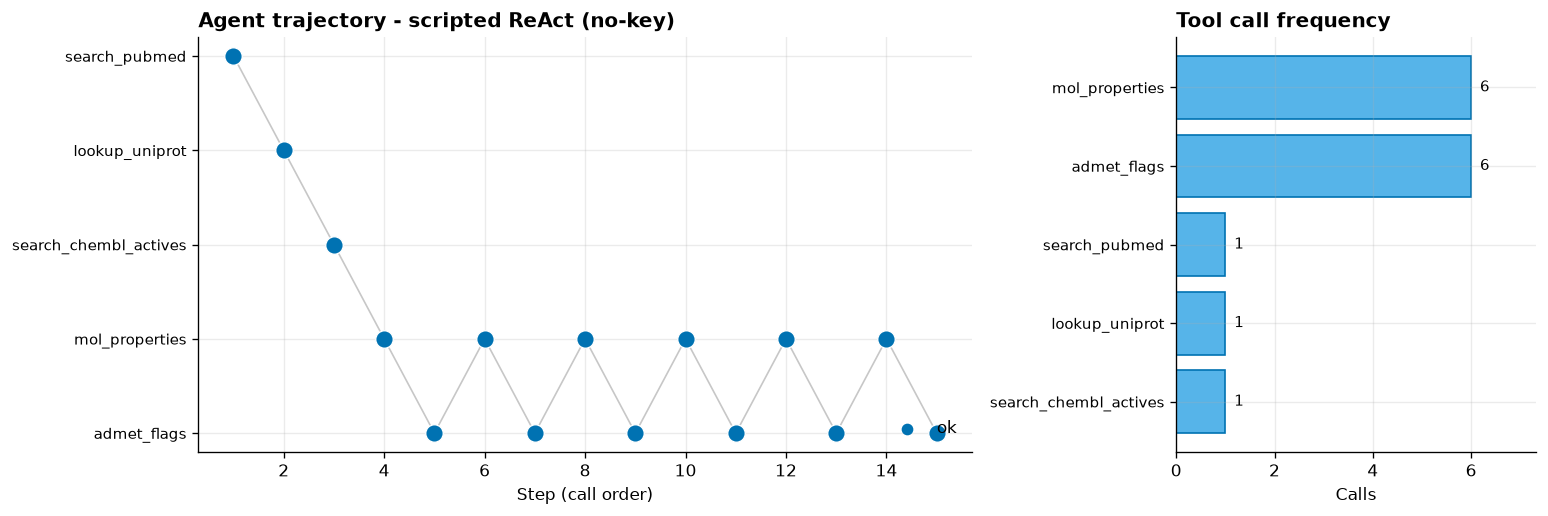

총 15 스텝. 물성/규칙 도구가 후보 수만큼 반복되는 것이 정상입니다
(후보 1건당 mol_properties 1회 + admet_flags 1회).
빨간 점은 그 스텝의 API 호출이 실패했다는 뜻 — 뒤 표에서 해당 행이 비게 됩니다.
왼쪽 그림이 곧 '에이전트가 스스로 세운 계획'입니다. 사람이 순서를 검산할 수 있어야 합니다.


In [8]:
# --- 5-0. 에이전트가 실제로 밟은 궤적을 그림으로 확인 ---
# 로그를 눈으로 훑는 것과 궤적을 한 장으로 보는 것은 다르다.
# 확인할 것: (1) 어떤 도구를 몇 번 썼나 (2) 실패한 호출이 있었나
#            (3) 계획이 '조사 → 후보 → 평가' 순서로 흘렀나.

_trace = result.get("trace", [])

def _step_ok(t):
    """경로 B 는 ok 키를 남기고, LLM 경로(A)는 남기지 않는다 → obs 로 판정."""
    return t["ok"] if t.get("ok") is not None else ("error" not in (t.get("obs") or {}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4),
                         gridspec_kw={"width_ratios": [2.15, 1]})

ax = axes[0]
if not _trace:
    _nodata(ax, "empty trace (agent called no tool)")
else:
    tools = list(dict.fromkeys(t["tool"] for t in _trace))   # 첫 등장 순서 유지
    ypos = {t: i for i, t in enumerate(tools)}
    ax.plot(range(1, len(_trace) + 1), [ypos[t["tool"]] for t in _trace],
            color=CB["grey"], lw=1.0, alpha=0.55, zorder=2)
    for i, t in enumerate(_trace):
        ax.scatter(i + 1, ypos[t["tool"]], s=110, zorder=3,
                   color=CB["blue"] if _step_ok(t) else CB["red"],
                   edgecolor="white", linewidth=0.8)
    ax.set_yticks(range(len(tools))); ax.set_yticklabels(tools, fontsize=9)
    ax.set_xlabel("Step (call order)")
    ax.set_title(f"Agent trajectory - {result.get('mode', '?')}", loc="left", fontweight="bold")
    ax.invert_yaxis()
    _nfail = sum(1 for t in _trace if not _step_ok(t))
    ax.scatter([], [], color=CB["blue"], label="ok")
    if _nfail:
        ax.scatter([], [], color=CB["red"], label=f"failed ({_nfail})")
    ax.legend(loc="lower right", frameon=False)

ax = axes[1]
if not _trace:
    _nodata(ax, "nothing to count")
else:
    from collections import Counter
    cnt = Counter(t["tool"] for t in _trace)
    names = [k for k, _ in cnt.most_common()][::-1]
    vals = [cnt[k] for k in names]
    ax.barh(names, vals, color=CB["sky"], edgecolor=CB["blue"])
    for y, v in enumerate(vals):
        ax.text(v + max(vals) * 0.03, y, str(v), va="center", fontsize=9)
    ax.set_xlabel("Calls"); ax.set_xlim(0, max(vals) * 1.22)
    ax.tick_params(axis="y", labelsize=9)
    ax.set_title("Tool call frequency", loc="left", fontweight="bold")

plt.tight_layout(); plt.show()
print(f"총 {len(_trace)} 스텝. 물성/규칙 도구가 후보 수만큼 반복되는 것이 정상입니다")
print("(후보 1건당 mol_properties 1회 + admet_flags 1회).")
print("빨간 점은 그 스텝의 API 호출이 실패했다는 뜻 — 뒤 표에서 해당 행이 비게 됩니다.")
print("왼쪽 그림이 곧 '에이전트가 스스로 세운 계획'입니다. 사람이 순서를 검산할 수 있어야 합니다.")


### 5-1. 결과 종합 → 마크다운 보고서 자동 생성
트레이스에서 **도구가 반환한 실제 값만** 뽑아 보고서를 조립한다 (LLM이 수치를 지어내지 않음).

In [9]:
from IPython.display import Markdown, display

def build_report(goal, target, result):
    """트레이스에 남은 도구 반환값만으로 마크다운 보고서를 조립한다."""
    ti = result.get("target_info")
    if ti is None:   # 경로 A(LLM)로 돈 경우: 트레이스에서 복원
        ti = {"pubmed": {}, "uniprot": {}, "chembl": {}}
        for t in result["trace"]:
            if t["tool"] == "search_pubmed": ti["pubmed"] = t["obs"]
            if t["tool"] == "lookup_uniprot": ti["uniprot"] = t["obs"]
            if t["tool"] == "search_chembl_actives": ti["chembl"] = t["obs"]
    up, pm, ch = ti["uniprot"], ti["pubmed"], ti["chembl"]

    # 후보별 물성/ADMET을 트레이스에서 취합
    props = {t["args"]["smiles"]: t["obs"] for t in result["trace"] if t["tool"] == "mol_properties" and "error" not in t["obs"]}
    admet = {t["args"]["smiles"]: t["obs"] for t in result["trace"] if t["tool"] == "admet_flags" and "error" not in t["obs"]}

    L = []
    L.append(f"# 자동 생성 보고서 — {target} 저해제 후보 조사\n")
    L.append(f"**목표:** {goal}\n")
    L.append(f"**에이전트 모드:** {result['mode']}\n")
    L.append("> 모든 수치·식별자는 도구 실계산/실API 값. LLM 생성 수치 없음.\n")

    L.append("## 1. 표적 (UniProt)")
    if up.get("accession"):
        L.append(f"- **{up.get('protein')}** (유전자 {up.get('gene')}, accession **{up.get('accession')}**, {up.get('length')} aa)")
        if up.get("function"): L.append(f"- 기능: {up['function']}")
        L.append(f"- 출처: {up.get('provenance')}")
    else:
        L.append(f"- 조회 실패: {up.get('error')}")

    L.append("\n## 2. 문헌 배경 (PubMed)")
    for p in pm.get("papers", []):
        L.append(f"- PMID {p['pmid']} ({p['year']}) — {p['title']} *{p['journal']}*")
    if not pm.get("papers"): L.append(f"- (문헌 없음/오류: {pm.get('error','')})")

    L.append(f"\n## 3. 후보 화합물 & 약물성 ({ch.get('target_chembl_id','?')})")
    L.append("| ChEMBL ID | pChEMBL | MW | logP | TPSA | QED | Ro5 | Veber | lead-like |")
    L.append("|---|---|---|---|---|---|---|---|---|")
    for a in ch.get("actives", []):
        smi = a["canonical_smiles"]; pr = props.get(smi); ad = admet.get(smi)
        if not pr or not ad: continue
        L.append(f"| {a['molecule_chembl_id']} | {a.get('pchembl_value','?')} | {pr['MW']} | {pr['logP']} | "
                 f"{pr['TPSA']} | {pr['QED']} | {'✅' if ad['lipinski_ro5']['pass'] else '❌'} | "
                 f"{'✅' if ad['veber']['pass'] else '❌'} | {'✅' if ad['lead_like']['pass'] else '❌'} |")

    npass = sum(1 for a in ch.get("actives", [])
                if admet.get(a["canonical_smiles"], {}).get("lipinski_ro5", {}).get("pass"))
    L.append(f"\n**요약:** 후보 {ch.get('n',0)}건 중 Lipinski Ro5 통과 {npass}건.")
    L.append("\n## 4. 한계 (정직한 서술)")
    L.append("- ADMET 컬럼은 **규칙기반 필터**(Lipinski/Veber/lead-like)이며 흡수·독성 ML 예측이 아니다.")
    L.append("- pChEMBL은 이질적 어세이의 집계값 — 직접 IC50 비교에는 주의.")
    L.append("- 이 결과는 **가설**이며 합성·효소 어세이 실검증이 별도로 필요하다.")
    L.append(f"- 출처: PubMed E-utilities, UniProt REST, ChEMBL REST, RDKit {Chem.rdBase.rdkitVersion}.")
    return "\n".join(L)

report_md = build_report(GOAL, TARGET, result)
display(Markdown(report_md))

# 파일로도 저장 (Colab에서 다운로드 가능)
with open("agent_report.md", "w") as f:
    f.write(report_md)
print("\n[저장] agent_report.md")


# 자동 생성 보고서 — EGFR 저해제 후보 조사

**목표:** EGFR 저해제 후보를 조사하고 약물성(drug-likeness)을 평가하라

**에이전트 모드:** scripted ReAct (no-key)

> 모든 수치·식별자는 도구 실계산/실API 값. LLM 생성 수치 없음.

## 1. 표적 (UniProt)
- **Epidermal growth factor receptor** (유전자 EGFR, accession **P00533**, 1210 aa)
- 기능: Receptor tyrosine kinase binding ligands of the EGF family and activating several signaling cascades to convert extracellular cues into appropriate cellular responses (PubMed:10805725, PubMed:12297050, PubMed:12620237, PubMed:12873986, PubMed:15374980, PubMed:15590694, PubMed:17115032, PubMed:19560417, PubMed:21258366, PubMed:27153536, PubMed:2790960, PubMed:35538033, PubMed:9488479). Known ligand
- 출처: UniProt REST (P00533)

## 2. 문헌 배경 (PubMed)
- PMID 42672009 (2026) — Computational identification and evaluation of Adenium obesum phytochemicals as potential EGFR inhibitors for targeted therapy against non-small-cell lung cancer *PloS one*
- PMID 42667711 (2026) — Design, synthesis, antitumor estimation, and molecular docking of new imidazothiazolediones as potential dual EGFR and IDO1 inhibitors and apoptosis stimulators *Bioorganic & medicinal chemistry*
- PMID 42656148 (2026) — Looking back on the history of epidermal growth factor receptor mutations in lung cancer *Philosophical transactions of the Royal Society of London. Series B, Biological sciences*
- PMID 42653913 (2026) — Phytochemical Profiling, In Vitro Bioactivity, and Network Pharmacology of Astragalus cruciatus Link Ethanolic Extract: Multitarget Mechanisms Underlying Potential Antidiabetic Effects *Molecules (Basel, Switzerland)*

## 3. 후보 화합물 & 약물성 (CHEMBL203)
| ChEMBL ID | pChEMBL | MW | logP | TPSA | QED | Ro5 | Veber | lead-like |
|---|---|---|---|---|---|---|---|---|
| CHEMBL68920 | 7.39 | 383.8 | 4.45 | 82.7 | 0.583 | ✅ | ✅ | ❌ |
| CHEMBL69960 | 6.77 | 482.9 | 3.61 | 112.2 | 0.49 | ✅ | ✅ | ❌ |
| CHEMBL137635 | 5.03 | 369.4 | 4.77 | 78.7 | 0.391 | ✅ | ✅ | ❌ |
| CHEMBL77085 | 4.02 | 215.2 | 1.73 | 111.0 | 0.458 | ✅ | ✅ | ✅ |
| CHEMBL443268 | 5.28 | 540.0 | 3.23 | 115.5 | 0.395 | ✅ | ✅ | ❌ |
| CHEMBL76589 | 6.90 | 236.2 | 1.56 | 117.6 | 0.596 | ✅ | ✅ | ✅ |

**요약:** 후보 6건 중 Lipinski Ro5 통과 6건.

## 4. 한계 (정직한 서술)
- ADMET 컬럼은 **규칙기반 필터**(Lipinski/Veber/lead-like)이며 흡수·독성 ML 예측이 아니다.
- pChEMBL은 이질적 어세이의 집계값 — 직접 IC50 비교에는 주의.
- 이 결과는 **가설**이며 합성·효소 어세이 실검증이 별도로 필요하다.
- 출처: PubMed E-utilities, UniProt REST, ChEMBL REST, RDKit 2026.03.5.


[저장] agent_report.md


### 5-2. 후보 화합물 구조 시각화 (RDKit Draw)
보고서 표의 화합물들을 실제 2D 구조로 그린다. (GitHub/Colab 출력에 PNG 임베드)

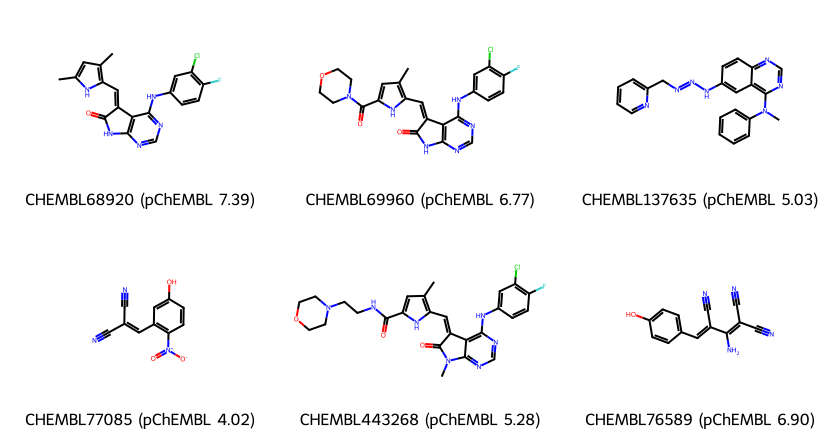

In [10]:
def draw_candidates(result, max_n=6):
    """트레이스의 ChEMBL 후보들을 RDKit 2D 구조 그리드로 그린다."""
    ch = None
    for t in result["trace"]:
        if t["tool"] == "search_chembl_actives": ch = t["obs"]
    if not ch or not ch.get("actives"):
        print("그릴 후보 없음"); return None
    mols, legends = [], []
    for a in ch["actives"][:max_n]:
        m = Chem.MolFromSmiles(a["canonical_smiles"])
        if m is None: continue
        mols.append(m)
        legends.append(f"{a['molecule_chembl_id']} (pChEMBL {a.get('pchembl_value','?')})")
    if not mols:
        print("유효 구조 없음"); return None
    img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(280, 220), legends=legends)
    return img

img = draw_candidates(result)
img  # 마지막 표현식 → 노트북 출력에 PNG 임베드


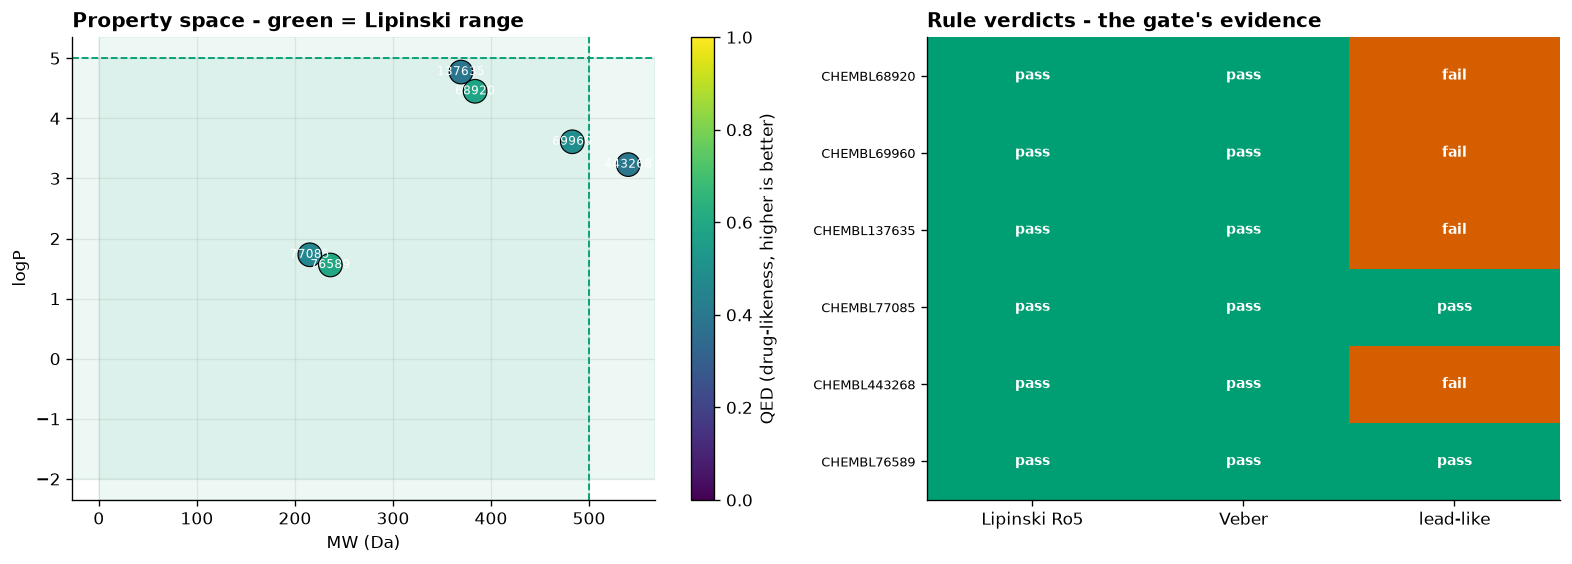

물성이 계산된 후보 6건 / ChEMBL 반환 6건.
주의: Lipinski 통과는 '경구 흡수 가능성이 있다'는 뜻일 뿐, 활성이나 안전성과 무관합니다.
      QED 도 사람이 만든 경험식이므로 순위를 그대로 신뢰하면 안 됩니다.
      색이 진한(QED 높은) 점이 곧 좋은 약이 아니라는 점을 학생들에게 강조하세요.


In [11]:
# --- 5-3. 후보들이 '약물 같은 공간'의 어디에 있나 ---
# 표의 숫자만으로는 후보들이 서로 얼마나 떨어져 있는지 감이 오지 않는다.
# 왼쪽: MW-logP 평면 + Lipinski 상자 / 오른쪽: 규칙별 통과·위반 매트릭스.
# 모든 값은 앞 단계 도구(mol_properties / admet_flags)가 RDKit 으로 실계산한 값이다.

import numpy as np

_props = {t["args"]["smiles"]: t["obs"] for t in result["trace"]
          if t["tool"] == "mol_properties" and "error" not in t["obs"]}
_admet = {t["args"]["smiles"]: t["obs"] for t in result["trace"]
          if t["tool"] == "admet_flags" and "error" not in t["obs"]}
_ch = next((t["obs"] for t in result["trace"] if t["tool"] == "search_chembl_actives"), {})
_cands = [a for a in _ch.get("actives", []) if a["canonical_smiles"] in _props]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8),
                         gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
if not _cands:
    _nodata(ax, "no candidate with computed properties\n(ChEMBL or RDKit tool call failed)")
else:
    # Lipinski Ro5 권장 구간: MW <= 500, logP <= 5
    ax.axvspan(0, 500, color=CB["green"], alpha=0.07)
    ax.axhspan(-2, 5, color=CB["green"], alpha=0.07)
    ax.axvline(500, color=CB["green"], ls="--", lw=1.1)
    ax.axhline(5, color=CB["green"], ls="--", lw=1.1)
    xs = [_props[a["canonical_smiles"]]["MW"] for a in _cands]
    ys = [_props[a["canonical_smiles"]]["logP"] for a in _cands]
    qs = [_props[a["canonical_smiles"]].get("QED", 0.0) for a in _cands]
    sc = ax.scatter(xs, ys, c=qs, cmap="viridis", vmin=0, vmax=1,
                    s=200, edgecolor="black", linewidth=0.7, zorder=3)
    for a, x, y in zip(_cands, xs, ys):
        ax.annotate(a["molecule_chembl_id"].replace("CHEMBL", ""), (x, y),
                    fontsize=7, ha="center", va="center", color="white", zorder=4)
    plt.colorbar(sc, ax=ax, label="QED (drug-likeness, higher is better)")
    ax.set_xlabel("MW (Da)"); ax.set_ylabel("logP")
    ax.set_title("Property space - green = Lipinski range", loc="left", fontweight="bold")

ax = axes[1]
_rules = [("lipinski_ro5", "Lipinski Ro5"), ("veber", "Veber"), ("lead_like", "lead-like")]
_rows = [a for a in _cands if a["canonical_smiles"] in _admet]
if not _rows:
    _nodata(ax, "no rule verdicts available")
else:
    M = np.array([[1 if _admet[a["canonical_smiles"]][k]["pass"] else 0 for k, _ in _rules]
                  for a in _rows])
    ax.imshow(M, cmap=mpl.colors.ListedColormap([CB["red"], CB["green"]]),
              vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(_rules))); ax.set_xticklabels([n for _, n in _rules])
    ax.set_yticks(range(len(_rows)))
    ax.set_yticklabels([a["molecule_chembl_id"] for a in _rows], fontsize=8)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, "pass" if M[i, j] else "fail", ha="center", va="center",
                    color="white", fontsize=8.5, fontweight="bold")
    ax.set_title("Rule verdicts - the gate's evidence", loc="left", fontweight="bold")
    ax.grid(False)

plt.tight_layout(); plt.show()
print(f"물성이 계산된 후보 {len(_cands)}건 / ChEMBL 반환 {_ch.get('n', 0)}건.")
print("주의: Lipinski 통과는 '경구 흡수 가능성이 있다'는 뜻일 뿐, 활성이나 안전성과 무관합니다.")
print("      QED 도 사람이 만든 경험식이므로 순위를 그대로 신뢰하면 안 됩니다.")
print("      색이 진한(QED 높은) 점이 곧 좋은 약이 아니라는 점을 학생들에게 강조하세요.")


## 6. 에이전트 고도화

실전 에이전트는 (1) 새 도구를 계속 붙이고, (2) 도구 실패를 스스로 회복하며, (3) 안전하게 운영된다.

### 6-1. 도구 추가하기
도구 추가 = **함수 구현 + JSON schema 등록 + dispatch 매핑**, 이 3단계뿐이다.
아래는 PubChem으로 화합물 이름/CID를 조회하는 새 도구를 붙이는 예시 (실제 PubChem PUG-REST 호출).

In [12]:
# (1) 새 도구 함수 — 실제 PubChem PUG-REST
def pubchem_lookup(name: str) -> dict:
    """화합물 이름 → PubChem CID + canonical SMILES + 분자식 (실 API)."""
    base = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"
    try:
        url = f"{base}/compound/name/{requests.utils.quote(name)}/property/CanonicalSMILES,MolecularFormula/JSON"
        r = requests.get(url, headers=UA, timeout=20)
        r.raise_for_status()
        props = r.json()["PropertyTable"]["Properties"][0]
        return {"name": name, "cid": props.get("CID"),
                "smiles": props.get("CanonicalSMILES"),
                "formula": props.get("MolecularFormula"),
                "provenance": "PubChem PUG-REST"}
    except Exception as e:
        return {"name": name, "error": f"{type(e).__name__}: {e}", "provenance": "PubChem (failed)"}

# (2) 스키마 등록  (3) dispatch 매핑
TOOLS_SCHEMA.append({
    "name": "pubchem_lookup",
    "description": "Look up a compound by name in PubChem. Returns CID, canonical SMILES, molecular formula.",
    "input_schema": {"type": "object", "properties": {"name": {"type": "string"}}, "required": ["name"]}})
TOOL_FUNCS["pubchem_lookup"] = pubchem_lookup

# 즉시 사용 가능
print("도구 추가 후 총", len(TOOL_FUNCS), "개")
print(call_tool("pubchem_lookup", {"name": "gefitinib"}))


도구 추가 후 총 6 개


{'name': 'gefitinib', 'cid': 123631, 'smiles': None, 'formula': 'C22H24ClFN4O3', 'provenance': 'PubChem PUG-REST'}


### 6-2. 실패 디버깅 — 재시도 & 폴백
네트워크 도구는 실패할 수 있다. 견고한 에이전트는 **지수 백오프 재시도** 후에도 실패하면
**대체 도구로 폴백** 한다 (그리고 수치를 지어내지 않는다).

In [13]:
def with_retry(fn, *args, tries=3, base_delay=0.6, **kw):
    """지수 백오프 재시도. 마지막 시도까지 실패하면 마지막 error 결과를 반환."""
    last = None
    for i in range(tries):
        obs = fn(*args, **kw)
        if "error" not in obs:
            if i: print(f"   재시도 {i}회 후 성공")
            return obs
        last = obs
        print(f"   시도 {i+1}/{tries} 실패: {obs.get('error','')[:60]} — {base_delay*2**i:.1f}s 대기")
        time.sleep(base_delay * 2 ** i)
    return last

def resolve_smiles(identifier: str) -> dict:
    """SMILES 확보: ChEMBL 우선 → 실패 시 PubChem 폴백 (무-날조: 둘 다 실패하면 error)."""
    # 일부러 실패하는 도구를 넣어 폴백을 시연
    def _broken(x): return {"error": "simulated outage"}
    obs = with_retry(_broken, identifier, tries=2)
    if "error" in obs:
        print("   → ChEMBL 계열 실패, PubChem으로 폴백")
        obs = with_retry(pubchem_lookup, identifier, tries=2)
    return obs

print("데모: 'imatinib' SMILES 확보 (1차 실패 → 폴백)")
r = resolve_smiles("imatinib")
print("결과:", {k: (str(v)[:50] if k=='smiles' else v) for k, v in r.items()})


데모: 'imatinib' SMILES 확보 (1차 실패 → 폴백)
   시도 1/2 실패: simulated outage — 0.6s 대기


   시도 2/2 실패: simulated outage — 1.2s 대기


   → ChEMBL 계열 실패, PubChem으로 폴백


결과: {'name': 'imatinib', 'cid': 5291, 'smiles': 'None', 'formula': 'C29H31N7O', 'provenance': 'PubChem PUG-REST'}


### 6-3. 자사 데이터 시나리오 & 안전(safety)

**자사 데이터로 확장:** 위 도구들의 API 호출부를 사내 자원으로 바꾸면 그대로 사내 에이전트가 된다 —
예) `search_chembl_actives` → 사내 HTS/어세이 DB 쿼리, `lookup_uniprot` → 사내 타겟 카드,
`search_pubmed` → 사내 문서 RAG(내부 보고서 벡터 검색). **스키마/dispatch 구조는 동일**하다.

**안전 3원칙 (실전 배치 시 필수):**
1. **권한 최소화(least privilege)** — 도구는 필요한 최소 범위만. 쓰기/삭제·결제·이메일 발송 등
   부작용 있는 도구는 사람 승인(HITL) 게이트 뒤에 둔다. (읽기 전용 우선)
2. **키 격리(secret isolation)** — API 키는 `os.environ`/시크릿 매니저로만. **코드·노트북·로그에 하드코딩 금지**,
   깃 커밋 금지. 이 노트북은 `getpass`/환경변수만 사용한다.
3. **감사 로그(audit trail)** — 모든 `{tool, args, obs, provenance, timestamp}` 를 남겨 재현·추적 가능하게.
   아래는 최소 감사 로거 예시.

In [14]:
import datetime
AUDIT_LOG = []
def audited_call(name, args):
    """도구 호출을 감사 로그(AUDIT_LOG)에 기록하면서 실행한다."""
    rec = {"ts": datetime.datetime.utcnow().isoformat() + "Z", "tool": name, "args": args}
    obs = call_tool(name, args)
    rec["ok"] = "error" not in obs
    rec["provenance"] = obs.get("provenance")
    AUDIT_LOG.append(rec)
    return obs

_ = audited_call("mol_properties", {"smiles": "CC(=O)Oc1ccccc1C(=O)O"})  # aspirin
_ = audited_call("lookup_uniprot", {"gene_or_id": "EGFR"})
print(json.dumps(AUDIT_LOG, indent=2, ensure_ascii=False))


/tmp/ipykernel_3498232/110728427.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  rec = {"ts": datetime.datetime.utcnow().isoformat() + "Z", "tool": name, "args": args}


[
  {
    "ts": "2026-09-02T14:27:45.740059Z",
    "tool": "mol_properties",
    "args": {
      "smiles": "CC(=O)Oc1ccccc1C(=O)O"
    },
    "ok": true,
    "provenance": "RDKit Descriptors/QED (real computation)"
  },
  {
    "ts": "2026-09-02T14:27:45.743369Z",
    "tool": "lookup_uniprot",
    "args": {
      "gene_or_id": "EGFR"
    },
    "ok": true,
    "provenance": "UniProt REST (P00533)"
  }
]


## 7. LLM-wiki: 검색 대신 구조화된 기억

지금까지 에이전트의 기억은 **트레이스(휘발성)** 뿐이었다. 세션이 끝나면 사라진다.
장기 기억을 붙이는 방법은 크게 두 갈래다.

| | **RAG** (Retrieval-Augmented Generation) | **LLM-wiki** (구조화된 기억) |
|---|---|---|
| 저장 단위 | **청크**(chunk) — 문서를 잘게 쪼갠 조각 | **페이지**(page) — 사람이 읽는 문서 1개 |
| 찾는 방식 | 임베딩 벡터 유사도(근사 최근접) | 색인(index) + 제목/키워드/링크 따라가기 |
| 규모 | **외부·사실상 무한** (수백만 문서 OK) | **내부·유한** (수십~수천 페이지) |
| 근거 추적 단위 | `문서id + 청크 인덱스` (사람이 열어보기 애매) | **파일 경로** (`wiki/decision_log.md`) — 열면 끝 |
| 갱신 | 문서 추가 → **재청킹·재임베딩·인덱스 재빌드** | 마크다운 파일 **수정/커밋** (git diff로 리뷰) |
| 구조 | 청크 경계에서 표·목록이 **잘림** | 표·링크·섹션이 **그대로 보존** |
| 비용 | 임베딩 모델 + 벡터DB | 파일시스템 + grep |

> ⚠️ **"LLM-wiki"는 표준 용어가 아니다.** 벤더 스펙도 논문 용어도 아니고,
> "에이전트가 스스로 쓰고 읽는 구조화된 마크다운 저장소"를 가리키는 **설계 패턴**의 별칭이다.
> (Claude Code의 `CLAUDE.md`, 사내 위키, `AGENTS.md`, 프로젝트 노트가 모두 같은 계열이다.)
> 논문에 "LLM-wiki 기법을 적용했다"고 쓰면 안 된다 — "구조화된 마크다운 메모리를 도구로 노출했다"가 정확하다.

**왜 신약개발에서 유용한가 — 감사(audit) 가능성.**
규제 환경에서 "이 후보를 왜 골랐나"에 답해야 할 때, RAG는 *"임베딩 top-3 청크가 이랬다"* 라고 답한다.
재현하려면 같은 임베딩 모델·같은 인덱스 버전이 필요하고, 인덱스를 재빌드하면 청크 번호가 바뀐다.
LLM-wiki는 *"`wiki/decision_log.md` 14번째 줄에 적혀 있다"* 라고 답한다.
**근거가 파일 경로라서 사람이 그냥 열어보고, `git log` 로 누가 언제 바꿨는지까지 본다.**

아래에서 (1) 앞 단계 **실제 API 결과**로 미니 위키를 만들고, (2) 위키 도구 2종을 에이전트에 등록하고,
(3) **같은 질문**을 RAG와 LLM-wiki 두 방식으로 답해 성질 차이를 나란히 본다.

### 7-1. 미니 위키 생성 — 앞 단계에서 **실제로 가져온 값만** 쓴다

무-날조 원칙: 위키 본문의 모든 수치·ID는 이 노트북이 **직접 호출한** UniProt/ChEMBL API 응답과
**RDKit 실계산** 결과다. `decision_log.md` 의 제외 사유 역시 **이번 실행에서 실제로 규칙에 걸린 화합물**만
기록한다 (지어낸 실패담 없음 — 걸린 게 없으면 "없었다"고 쓴다). 각 페이지 끝에는 `source:` 줄로
출처 URL/ID와 계산 시각을 남긴다.

선별은 실무에서 흔한 **2단 게이트**로 한다 (둘 다 RDKit 실계산값에 규칙을 적용):
- **Tier 1 — drug-like 게이트**: Lipinski Ro5 통과(위반 ≤1) **AND** Veber 통과(RotB≤10, TPSA≤140)
- **Tier 2 — lead-like 쇼트리스트**: Tier 1 통과분 중 MW≤350 **AND** logP≤3.5
  (최적화 여지를 남기려고 출발점을 작게 잡는 관행. 여기서 걸리면 "나쁜 분자"가 아니라 "이번 쇼트리스트 밖")

In [15]:
import datetime, pathlib, re

WIKI_DIR = pathlib.Path("wiki"); WIKI_DIR.mkdir(exist_ok=True)
NOW = datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

# ---- (1) 앞 단계 트레이스에서 '실제로 가져온 값'만 회수 ----------------------
_ti = result.get("target_info") or {}
def _from_trace(tool):
    return next((t["obs"] for t in result["trace"] if t["tool"] == tool), {})
W_UP = _ti.get("uniprot") or _from_trace("lookup_uniprot")
W_PM = _ti.get("pubmed")  or _from_trace("search_pubmed")
W_CH = _ti.get("chembl")  or _from_trace("search_chembl_actives")
W_PROPS = {t["args"]["smiles"]: t["obs"] for t in result["trace"]
           if t["tool"] == "mol_properties" and "error" not in t["obs"]}
W_ADMET = {t["args"]["smiles"]: t["obs"] for t in result["trace"]
           if t["tool"] == "admet_flags" and "error" not in t["obs"]}
FAILED_CALLS = [t for t in result["trace"] if t.get("ok") is False]

# ---- (2) 이번 실행에서 '실제로' 2단 게이트 판정 ------------------------------
SHORTLIST, DROP_T1, DROP_T2 = [], [], []
for a in W_CH.get("actives", []):
    smi = a["canonical_smiles"]
    pr, ad = W_PROPS.get(smi), W_ADMET.get(smi)
    if not pr or not ad:
        DROP_T1.append((a, None, "Tier 1", "물성/규칙 도구 결과 없음 (도구 호출 실패)")); continue
    t1 = []
    if not ad["lipinski_ro5"]["pass"]:
        t1.append("Lipinski Ro5 위반 " + ",".join(k for k, v in ad["lipinski_ro5"]["detail"].items() if not v))
    if not ad["veber"]["pass"]:
        t1.append("Veber 위반 " + ",".join(k for k, v in ad["veber"]["detail"].items() if not v))
    if t1:
        DROP_T1.append((a, pr, "Tier 1", "; ".join(t1))); continue
    if not ad["lead_like"]["pass"]:
        why = "lead-like 미달 " + ",".join(k for k, v in ad["lead_like"]["detail"].items() if not v)
        DROP_T2.append((a, pr, "Tier 2", why))
    else:
        SHORTLIST.append((a, pr, ad))
DROPPED = DROP_T1 + DROP_T2

TGT = W_UP.get("gene") or TARGET
TARGET_PAGE = f"target_{TGT}"
_acc = W_UP.get("accession")
_uniprot_url = f"https://rest.uniprot.org/uniprotkb/{_acc}.json" if _acc else "UniProt REST (조회 실패)"

def _w(name, text):
    p = WIKI_DIR / f"{name}.md"
    p.write_text(text.rstrip() + "\n", encoding="utf-8")
    return p

# ---- (3-a) 표적 페이지 -------------------------------------------------------
L = [f"# Target: {TGT}", ""]
if _acc:
    L += [f"- **UniProt accession**: {_acc}",
          f"- **Protein**: {W_UP.get('protein')}",
          f"- **Gene**: {W_UP.get('gene')}",
          f"- **Sequence length**: {W_UP.get('length')} aa"]
    if W_UP.get("function"):
        L += ["", "## Function (UniProt FUNCTION comment, 원문 발췌)", W_UP["function"]]
else:
    L += [f"- 조회 실패: {W_UP.get('error')}  ← 무-날조: 값을 채우지 않고 실패를 기록"]
L += ["", "## 문헌 앵커 (이번 실행에서 PubMed 실조회)"]
for p in W_PM.get("papers", []):
    L.append(f"- PMID {p['pmid']} ({p['year']}) — {p['title']} *{p['journal']}*")
if not W_PM.get("papers"):
    L.append(f"- (문헌 없음/오류: {W_PM.get('error','')})")
L += ["", "## 관련 페이지", "- [[compound_cards]] — 이 표적의 활성 화합물 카드 + RDKit 실계산 물성",
      "- [[decision_log]] — 후보 선별/제외 기록", "",
      f"source: {_uniprot_url} | UniProt REST | fetched {NOW}"]
p_target = _w(TARGET_PAGE, "\n".join(L))

# ---- (3-b) 화합물 카드 -------------------------------------------------------
tid = W_CH.get("target_chembl_id", "?")
L = [f"# Compound cards — {TGT} actives (ChEMBL target {tid})", "",
     f"ChEMBL REST 실조회 화합물 {W_CH.get('n', 0)}건. 물성 컬럼은 **RDKit {Chem.rdBase.rdkitVersion} 실계산**.", "",
     "| ChEMBL ID | pChEMBL | MW | logP | TPSA | HBD | HBA | RotB | QED | Ro5 | Veber | lead-like |",
     "|---|---|---|---|---|---|---|---|---|---|---|---|"]
CARD_ROWS = []
for a in W_CH.get("actives", []):
    smi = a["canonical_smiles"]; pr, ad = W_PROPS.get(smi), W_ADMET.get(smi)
    if not pr or not ad:
        continue
    row = (f"| {a['molecule_chembl_id']} | {a.get('pchembl_value','?')} | {pr['MW']} | {pr['logP']} | "
           f"{pr['TPSA']} | {pr['HBD']} | {pr['HBA']} | {pr['RotB']} | {pr['QED']} | "
           f"{'PASS' if ad['lipinski_ro5']['pass'] else 'FAIL'} | "
           f"{'PASS' if ad['veber']['pass'] else 'FAIL'} | "
           f"{'PASS' if ad['lead_like']['pass'] else 'FAIL'} |")
    L.append(row); CARD_ROWS.append(row)
L += ["", "## SMILES (ChEMBL canonical, 원문 그대로)"]
for a in W_CH.get("actives", []):
    L.append(f"- {a['molecule_chembl_id']}: `{a['canonical_smiles']}`")
L += ["", "## 관련 페이지", f"- [[{TARGET_PAGE}]] — 표적 배경", "- [[decision_log]] — 이 중 무엇을 왜 걸렀나", "",
      f"source: ChEMBL REST (target {tid}, standard_type=IC50, pChEMBL not null) | "
      f"RDKit {Chem.rdBase.rdkitVersion} computed at {NOW}"]
p_cards = _w("compound_cards", "\n".join(L))

# ---- (3-c) 의사결정 로그 — 이번 실행에서 '실제로' 일어난 일만 ----------------
L = [f"# Decision log — {TGT} 후보 선별 ({NOW})", "",
     "이 로그는 **이번 실행에서 실제로 일어난 일만** 적는다. 가상의 실패담 없음.", "",
     "## 실행 요약",
     f"- 에이전트 모드: {result['mode']}",
     f"- 도구 호출 총 {len(result['trace'])}회, 실패 {len(FAILED_CALLS)}회",
     f"- ChEMBL 요청: target=\"{W_CH.get('target')}\" → 유효 화합물 {W_CH.get('n', 0)}건 회수 "
     f"(중복 molecule_chembl_id · RDKit 파싱 실패 항목은 도구 내부에서 이미 제외)",
     "- Tier 1 게이트: Lipinski Ro5(위반 ≤1) AND Veber(RotB≤10, TPSA≤140)",
     "- Tier 2 쇼트리스트: Tier 1 통과분 중 MW≤350 AND logP≤3.5 (lead-like)",
     f"- **결과: 최종 쇼트리스트 {len(SHORTLIST)}건 / 제외 {len(DROPPED)}건 "
     f"(Tier 1 {len(DROP_T1)}건, Tier 2 {len(DROP_T2)}건)**", "",
     "## 제외된 후보 (실제로 규칙에 걸린 것만)"]
if DROPPED:
    L += ["| ChEMBL ID | 걸린 게이트 | 제외 사유 | 근거 수치 (RDKit 실계산) |", "|---|---|---|---|"]
    for a, pr, tier, why in DROPPED:
        ev = (f"MW={pr['MW']}, logP={pr['logP']}, TPSA={pr['TPSA']}, HBD={pr['HBD']}, "
              f"HBA={pr['HBA']}, RotB={pr['RotB']}") if pr else "n/a"
        L.append(f"| {a['molecule_chembl_id']} | {tier} | {why} | {ev} |")
else:
    L.append("- **이번 실행에서는 규칙에 걸려 제외된 후보가 없었다.** (없는 실패를 지어내지 않는다)")
L += ["", "## 최종 쇼트리스트 (Tier 1 + Tier 2 모두 통과)"]
if SHORTLIST:
    L += ["| ChEMBL ID | pChEMBL | MW | logP | QED |", "|---|---|---|---|---|"]
    for a, pr, ad in SHORTLIST:
        L.append(f"| {a['molecule_chembl_id']} | {a.get('pchembl_value','?')} | {pr['MW']} | "
                 f"{pr['logP']} | {pr['QED']} |")
else:
    L.append("- **비어 있음** — 이번 회수분 중 lead-like 쇼트리스트에 남은 화합물이 없다. "
             "규칙을 완화하거나 다른 화학 시리즈를 회수해야 한다.")
if FAILED_CALLS:
    L += ["", "## 실패한 도구 호출 (실제 로그)"]
    for t in FAILED_CALLS:
        L.append(f"- `{t['tool']}({t['args']})` → {str(t['obs'].get('error'))[:120]}")
L += ["", "## 알려진 한계 (이 로그 자체의)",
      "- 두 게이트 모두 **규칙기반 필터**이며 ADMET ML 예측이 아니다. 제외 = '흡수 안 됨'이 아니라 '규칙 밖'이다.",
      "- pChEMBL은 이질적 어세이 집계값 — 후보 간 직접 비교에 주의.",
      "- 회수 화합물은 ChEMBL IC50 상위 일부이며 전수가 아니다 (네트워크·DB 갱신에 따라 달라짐).", "",
      "## 관련 페이지", f"- [[{TARGET_PAGE}]]", "- [[compound_cards]]", "",
      f"source: this notebook run at {NOW} | tools: ChEMBL REST, UniProt REST, "
      f"RDKit {Chem.rdBase.rdkitVersion}"]
p_log = _w("decision_log", "\n".join(L))

# ---- (3-d) 색인 --------------------------------------------------------------
L = ["# Wiki index", "",
     f"에이전트의 구조화된 기억. 생성 시각 {NOW}. 모든 수치는 실 API 응답/실계산 값.", "",
     "| 페이지 | 한 줄 요약 |", "|---|---|",
     f"| [[{TARGET_PAGE}]] | 표적 {TGT} 의 UniProt 정체(accession/길이/기능) + PubMed 문헌 앵커 |",
     f"| [[compound_cards]] | ChEMBL 활성 화합물 {len(CARD_ROWS)}건의 ID·SMILES·RDKit 물성 표 |",
     f"| [[decision_log]] | 2단 게이트 선별 기록 (쇼트리스트 {len(SHORTLIST)} / 제외 {len(DROPPED)}) |",
     "", "## 사용법", "- `search_wiki(query)` — 제목·본문 키워드로 후보 페이지 찾기 (임베딩 불필요)",
     "- `read_wiki(page)` — 페이지 전문 읽기 (근거 = 파일 경로)", "",
     f"source: generated by nb1_scientific_agent.ipynb at {NOW}"]
p_index = _w("index", "\n".join(L))

print("생성된 위키 페이지:")
for p in (p_index, p_target, p_cards, p_log):
    print(f"  {p}  ({p.stat().st_size} bytes, {len(p.read_text(encoding='utf-8').splitlines())} lines)")
print(f"\n이번 실행의 실제 선별 결과: 쇼트리스트 {len(SHORTLIST)}건 / "
      f"제외 {len(DROPPED)}건 (Tier1 {len(DROP_T1)}, Tier2 {len(DROP_T2)})")
for a, pr, tier, why in DROPPED:
    print(f"  - {a['molecule_chembl_id']}: [{tier}] {why}")


생성된 위키 페이지:
  wiki/index.md  (707 bytes, 15 lines)
  wiki/target_EGFR.md  (1794 bytes, 21 lines)
  wiki/compound_cards.md  (1515 bytes, 26 lines)
  wiki/decision_log.md  (2062 bytes, 36 lines)

이번 실행의 실제 선별 결과: 쇼트리스트 2건 / 제외 4건 (Tier1 0, Tier2 4)
  - CHEMBL68920: [Tier 2] lead-like 미달 MW<=350,logP<=3.5
  - CHEMBL69960: [Tier 2] lead-like 미달 MW<=350,logP<=3.5
  - CHEMBL137635: [Tier 2] lead-like 미달 MW<=350,logP<=3.5
  - CHEMBL443268: [Tier 2] lead-like 미달 MW<=350


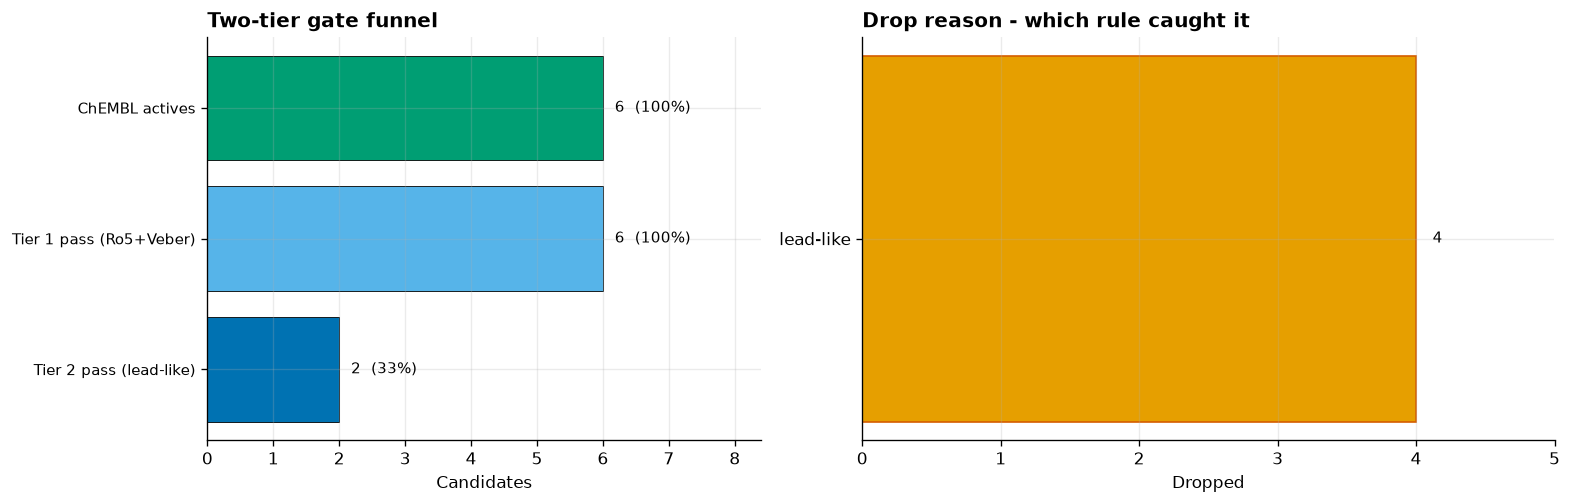

통과 2건 / 탈락 4건 (Tier 1 0건, Tier 2 4건).
이 그림이 곧 위키 target 페이지의 '왜 떨어졌는가' 절과 같은 내용입니다 —
에이전트의 판단 근거를 사람이 검산할 수 있어야 한다는 것이 이 절의 요점입니다.


In [16]:
# --- 7-1b. 2단 게이트가 후보를 얼마나 걸러냈나 ---
# 위키에 적어 넣은 판정을 그림으로 되짚는다. 숫자는 바로 위 셀이 계산한 그 값이다.

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.3),
                         gridspec_kw={"width_ratios": [1, 1.25]})

_n_in = len(W_CH.get("actives", []))
_stages = [("ChEMBL actives", _n_in),
           ("Tier 1 pass (Ro5+Veber)", _n_in - len(DROP_T1)),
           ("Tier 2 pass (lead-like)", len(SHORTLIST))]

ax = axes[0]
if _n_in == 0:
    _nodata(ax, "no ChEMBL candidates")
else:
    names = [s[0] for s in _stages][::-1]
    vals = [s[1] for s in _stages][::-1]
    ax.barh(names, vals, color=[CB["blue"], CB["sky"], CB["green"]],
            edgecolor="black", linewidth=0.5)
    for y, v in enumerate(vals):
        ax.text(v + max(vals) * 0.03, y, f"{v}  ({100 * v / _n_in:.0f}%)",
                va="center", fontsize=9)
    ax.set_xlim(0, max(vals) * 1.4); ax.set_xlabel("Candidates")
    ax.tick_params(axis="y", labelsize=9)
    ax.set_title("Two-tier gate funnel", loc="left", fontweight="bold")

ax = axes[1]
_RULE_EN = {"Lipinski Ro5": "Lipinski Ro5", "Veber": "Veber", "lead-like": "lead-like"}
_reasons = []
for _a, _pr, _tier, _why in DROPPED:
    _hit = False
    for part in _why.split(";"):
        part = part.strip()
        if not part:
            continue
        head = part.split(" 위반")[0].split(" 미달")[0].strip()
        if head in _RULE_EN:                 # 규칙 이름은 원래 ASCII 라 그대로 쓴다
            _reasons.append(_RULE_EN[head]); _hit = True
    if not _hit:                             # 도구 호출 실패 등 규칙 외 사유
        _reasons.append("no property data")
if not _reasons:
    _nodata(ax, "no candidate dropped - all passed" if _n_in else "nothing to judge")
else:
    from collections import Counter
    c = Counter(_reasons)
    ks = [k for k, _ in c.most_common()][::-1]
    vs = [c[k] for k in ks]
    ax.barh(ks, vs, color=CB["orange"], edgecolor=CB["red"])
    for y, v in enumerate(vs):
        ax.text(v + max(vs) * 0.03, y, str(v), va="center", fontsize=9)
    ax.set_xlim(0, max(vs) * 1.25); ax.set_xlabel("Dropped")
    ax.set_title("Drop reason - which rule caught it", loc="left", fontweight="bold")

plt.tight_layout(); plt.show()
print(f"통과 {len(SHORTLIST)}건 / 탈락 {len(DROPPED)}건 "
      f"(Tier 1 {len(DROP_T1)}건, Tier 2 {len(DROP_T2)}건).")
if FAILED_CALLS:
    print(f"※ 도구 호출 실패 {len(FAILED_CALLS)}건이 있어 그 후보는 '판정 불가'로 빠졌습니다.")
print("이 그림이 곧 위키 target 페이지의 '왜 떨어졌는가' 절과 같은 내용입니다 —")
print("에이전트의 판단 근거를 사람이 검산할 수 있어야 한다는 것이 이 절의 요점입니다.")


### 7-2. 위키 도구 2종 등록 — `search_wiki` / `read_wiki`

도구 추가는 6-1에서 본 3단계 그대로다: **함수 구현 → JSON schema 등록 → dispatch 매핑**.

- `search_wiki(query)` — 제목·본문 **키워드 매칭**. 임베딩 모델도 벡터DB도 없다.
  중요한 건 **왜 매칭됐는지**(어떤 토큰이 어느 줄에서 맞았는지)를 같이 돌려준다는 점 —
  RAG의 코사인 점수(`0.83`)보다 사람이 검증하기 쉽다.
  모든 페이지에 나오는 흔한 토큰은 **변별력이 없으므로 점수에서 뺀다** (IDF의 아이디어를 최소 형태로).
  `[[링크]]` 를 파싱해 **관련 페이지도 함께** 제시한다 (그래프 탐색).
- `read_wiki(page)` — 페이지 **전문**을 반환. provenance는 **파일 경로**.

In [17]:
# ---- (1) 함수 구현 ---------------------------------------------------------
WIKI_LINK_RE = re.compile(r"\[\[([^\]]+)\]\]")

def _wiki_pages():
    return sorted(p.stem for p in WIKI_DIR.glob("*.md"))

def read_wiki(page: str) -> dict:
    """위키 페이지 전문을 반환. provenance = 파일 경로 (사람이 그냥 열어볼 수 있음)."""
    page = page.strip()
    page = page[:-3] if page.endswith(".md") else page
    path = WIKI_DIR / f"{page}.md"
    if not path.exists():
        return {"page": page, "error": "page not found", "available": _wiki_pages(),
                "provenance": f"{WIKI_DIR}/ (filesystem)"}
    text = path.read_text(encoding="utf-8")
    src = next((l for l in text.splitlines() if l.startswith("source:")), None)
    return {"page": page, "path": str(path), "n_lines": len(text.splitlines()),
            "n_chars": len(text), "links": WIKI_LINK_RE.findall(text),
            "source_line": src, "content": text,
            "provenance": f"file://{path.resolve()}"}

def search_wiki(query: str, k: int = 3) -> dict:
    """제목·본문 키워드 매칭으로 후보 페이지를 찾는다. 임베딩 없음 — 왜 맞았는지 근거를 함께 반환."""
    pages = _wiki_pages()
    texts = {p: (WIKI_DIR / f"{p}.md").read_text(encoding="utf-8") for p in pages}
    # 한/영 혼용 질의 토큰화 (2자 이상, 'lead-like' 같은 하이픈 용어 유지)
    toks = [t.lower() for t in re.findall(r"[A-Za-z0-9][A-Za-z0-9\-\.]+|[가-힣]{2,}", query)]
    toks = sorted({t for t in toks if len(t) >= 2})
    # 최소 IDF: 모든 페이지에 등장하는 토큰은 변별력이 없으므로 점수에서 제외 (근거로도 안 씀)
    df = {t: sum(1 for p in pages if t in texts[p].lower() or t in p.lower()) for t in toks}
    common = [t for t in toks if pages and df[t] == len(pages)]
    useful = [t for t in toks if t not in common]
    hits = []
    for page in pages:
        lines = texts[page].splitlines()
        matched, evidence = {}, []
        for t in useful:
            in_title = t in page.lower()
            line_hits = [(i + 1, l.strip()) for i, l in enumerate(lines) if t in l.lower()]
            cnt = len(line_hits) + (3 if in_title else 0)      # 제목 매칭 가중치 3
            if cnt:
                matched[t] = cnt
                ln, lt = line_hits[0] if line_hits else (1, lines[0])
                evidence.append({"term": t, "count": cnt, "in_title": in_title,
                                 "line_no": ln, "line": lt[:110]})
        if matched:
            evidence.sort(key=lambda e: (-e["count"], e["line_no"]))   # 변별력 큰 근거부터
            hits.append({"page": page, "path": str(WIKI_DIR / f"{page}.md"),
                         "score": sum(matched.values()), "matched_terms": matched,
                         "why": evidence[:4], "links": WIKI_LINK_RE.findall(texts[page])})
    hits.sort(key=lambda h: -h["score"])
    top = hits[:k]
    related = sorted({l for h in top for l in h["links"]} - {h["page"] for h in top})
    return {"query": query, "tokens": useful, "dropped_common_terms": common,
            "n_hits": len(hits), "hits": top, "related_pages": related,
            "all_pages": pages, "provenance": f"keyword match over {WIKI_DIR}/*.md (no embeddings)"}

# ---- (2) 스키마 등록  (3) dispatch 매핑 (재실행해도 중복 등록 안 되게) -------
for _spec in [
    {"name": "search_wiki",
     "description": "Search the agent's structured markdown wiki by keyword. Returns candidate pages "
                    "with the matched terms and the exact line where each matched, plus related pages "
                    "from [[wiki links]]. No embeddings involved.",
     "input_schema": {"type": "object",
        "properties": {"query": {"type": "string"}, "k": {"type": "integer", "default": 3}},
        "required": ["query"]}},
    {"name": "read_wiki",
     "description": "Read a full wiki page by name (e.g. 'decision_log'). Returns the whole page text "
                    "with the file path as provenance, so structure (tables, links) is preserved.",
     "input_schema": {"type": "object",
        "properties": {"page": {"type": "string"}}, "required": ["page"]}},
]:
    if not any(t["name"] == _spec["name"] for t in TOOLS_SCHEMA):
        TOOLS_SCHEMA.append(_spec)
TOOL_FUNCS["search_wiki"] = search_wiki
TOOL_FUNCS["read_wiki"] = read_wiki
print("등록된 도구:", len(TOOL_FUNCS), "→", list(TOOL_FUNCS))

# ---- 즉시 동작 확인 (실제 파일에서 실제 내용을 읽는지) ----------------------
q = "lead-like 게이트에서 제외된 화합물"
s = call_tool("search_wiki", {"query": q})
print(f"\n● search_wiki({q!r})")
print("   사용 토큰:", s["tokens"], "| 변별력 없어 버린 토큰:", s["dropped_common_terms"])
for h in s["hits"]:
    print(f"   [score {h['score']:>2}] {h['page']:<16} {h['path']}")
    for e in h["why"]:
        print(f"        └ '{e['term']}' ×{e['count']} @ line {e['line_no']}: {e['line'][:78]}")
print("   관련 페이지([[링크]] 따라가기):", s["related_pages"])

r = call_tool("read_wiki", {"page": s["hits"][0]["page"] if s["hits"] else "index"})
print(f"\n● read_wiki('{r['page']}') → {r['n_lines']} lines, {r['n_chars']} chars")
print("   provenance:", r["provenance"])
print("  ", r.get("source_line", ""))
print("--- 본문 앞 22줄 ---")
print("\n".join(r["content"].splitlines()[:22]))


등록된 도구: 8 → ['search_pubmed', 'lookup_uniprot', 'search_chembl_actives', 'mol_properties', 'admet_flags', 'pubchem_lookup', 'search_wiki', 'read_wiki']

● search_wiki('lead-like 게이트에서 제외된 화합물')
   사용 토큰: ['lead-like', '게이트에서', '제외된'] | 변별력 없어 버린 토큰: ['화합물']
   [score  6] decision_log     wiki/decision_log.md
        └ 'lead-like' ×5 @ line 10: - Tier 2 쇼트리스트: Tier 1 통과분 중 MW≤350 AND logP≤3.5 (lead-like)
        └ '제외된' ×1 @ line 13: ## 제외된 후보 (실제로 규칙에 걸린 것만)
   [score  1] compound_cards   wiki/compound_cards.md
        └ 'lead-like' ×1 @ line 5: | ChEMBL ID | pChEMBL | MW | logP | TPSA | HBD | HBA | RotB | QED | Ro5 | Vebe
   관련 페이지([[링크]] 따라가기): ['target_EGFR']

● read_wiki('decision_log') → 36 lines, 1522 chars
   provenance: file:///tmp/nb1_run/wiki/decision_log.md
   source: this notebook run at 2026-09-02T14:27:47Z | tools: ChEMBL REST, UniProt REST, RDKit 2026.03.5
--- 본문 앞 22줄 ---
# Decision log — EGFR 후보 선별 (2026-09-02T14:27:47Z)

이 로그는 **이번 실행에서 실제로 일어난 일만** 적는다. 가상의 실패담 없음.



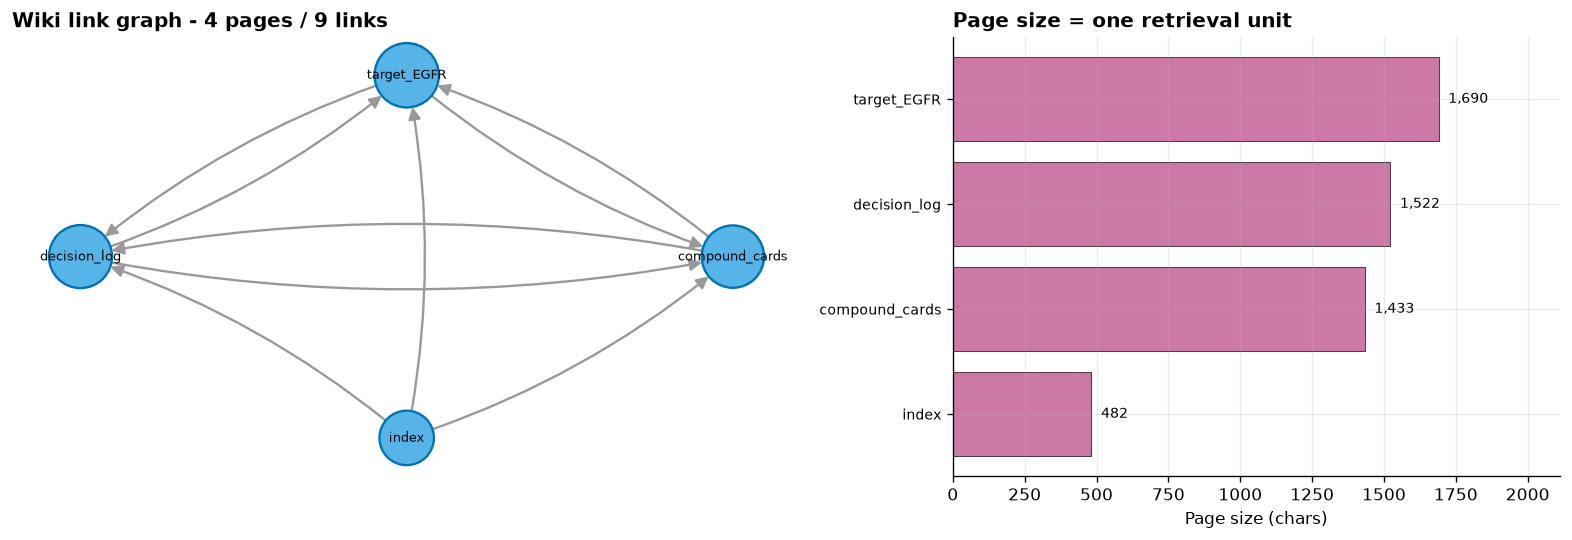

노드 크기 = 페이지 분량, 화살표 = [[링크]] 방향.
RAG 에는 이 그림에 해당하는 것이 없습니다 — 청크는 서로 연결 정보를 갖지 않습니다.
뒤의 하이브리드 검색이 바로 이 화살표를 타고 스코프를 넓힙니다.


In [18]:
# --- 7-2b. 위키의 [[링크]] 구조를 그래프로 ---
# RAG 의 청크는 서로 아무 관계가 없다. 위키는 [[링크]]로 이어져 있어
# '한 페이지에서 이웃으로 넓히기'가 가능하다 — 이 차이를 눈으로 본다.

import networkx as nx

_pages = _wiki_pages()
G = nx.DiGraph()
for p in _pages:
    _r = read_wiki(p)
    G.add_node(p, n_chars=_r.get("n_chars", 0))
    for l in _r.get("links", []):
        l = l.strip()
        if l in _pages and l != p:
            G.add_edge(p, l)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6),
                         gridspec_kw={"width_ratios": [1.3, 1]})

ax = axes[0]
if G.number_of_nodes() == 0:
    _nodata(ax, "no wiki page")
else:
    pos = nx.circular_layout(G) if G.number_of_nodes() > 2 else nx.spring_layout(G, seed=42)
    sizes = [900 + 0.35 * G.nodes[n]["n_chars"] for n in G.nodes]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=CB["grey"], width=1.4,
                           arrowsize=15, connectionstyle="arc3,rad=0.10",
                           node_size=sizes)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes,
                           node_color=CB["sky"], edgecolors=CB["blue"], linewidths=1.4)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
    ax.set_title(f"Wiki link graph - {G.number_of_nodes()} pages / {G.number_of_edges()} links",
                 loc="left", fontweight="bold")
    ax.set_axis_off()

ax = axes[1]
if not _pages:
    _nodata(ax, "nothing to count")
else:
    _sz = sorted(((p, read_wiki(p).get("n_chars", 0)) for p in _pages), key=lambda x: x[1])
    _mx = max(n for _, n in _sz) or 1
    ax.barh([p for p, _ in _sz], [n for _, n in _sz], color=CB["purple"],
            edgecolor="black", linewidth=0.4)
    for y, (_, n) in enumerate(_sz):
        ax.text(n + _mx * 0.02, y, f"{n:,}", va="center", fontsize=8.5)
    ax.set_xlim(0, _mx * 1.25)
    ax.set_xlabel("Page size (chars)")
    ax.tick_params(axis="y", labelsize=8.5)
    ax.set_title("Page size = one retrieval unit", loc="left", fontweight="bold")

plt.tight_layout(); plt.show()
print("노드 크기 = 페이지 분량, 화살표 = [[링크]] 방향.")
print("RAG 에는 이 그림에 해당하는 것이 없습니다 — 청크는 서로 연결 정보를 갖지 않습니다.")
print("뒤의 하이브리드 검색이 바로 이 화살표를 타고 스코프를 넓힙니다.")


### 7-3. ⭐ RAG vs LLM-wiki — **같은 질문**을 두 방식으로

같은 위키 문서를 대상으로, 같은 질문을 두 경로로 답하고 **무엇이 근거로 돌아오는지** 비교한다.

- **(A) 간이 RAG** — 위키 문서를 고정 길이 청크로 쪼개 **TF-IDF**(scikit-learn)로 top-k 검색 → 청크만 주입.
- **(B) LLM-wiki** — `search_wiki` 로 페이지를 고르고 `read_wiki` 로 **페이지 통째로** 읽기.

질문은 **표를 요구하도록** 골랐다: 후보별 물성 표(`compound_cards`)와 제외 사유(`decision_log`)를
같이 봐야 답할 수 있는 질문. 표는 청킹의 약점이 가장 잘 드러나는 자료형이다.

> **정직하게:** TF-IDF는 실제 임베딩 RAG(예: `text-embedding-3`, `bge-m3` + FAISS)의 **단순화 버전**이다.
> 임베딩 RAG는 어휘가 달라도 의미로 찾아내므로 **재현율(recall)이 TF-IDF보다 훨씬 좋다** — 여기서
> 보려는 건 검색 성능 우열이 **아니다**. 두 방식 모두 "문서를 청크로 잘라 조각을 주입한다"는
> 성질을 공유하며, 거기서 나오는 **구조 손실 · 근거 추적 단위 · 갱신 비용**의 차이가 관전 포인트다.
> (무거운 임베딩 모델 다운로드를 피하려고 TF-IDF를 쓴다 — 무료·CPU 원칙.)

In [19]:
# ---- 간이 RAG 구성: 위키 → 청크 → TF-IDF 인덱스 ---------------------------
try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
    _HAS_SK = True
except ImportError:                      # Colab엔 기본 설치되어 있음. 없으면 설치 시도.
    ensure({"sklearn": "scikit-learn"})
    try:
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.metrics.pairwise import cosine_similarity
        _HAS_SK = True
    except ImportError:
        _HAS_SK = False
        print("sklearn 사용 불가 → 순수 파이썬 문자 3-gram 코사인으로 폴백")

CHUNK_LINES, CHUNK_OVERLAP = 6, 2        # 전형적 RAG 설정: 고정 크기 + 겹침

def build_chunks():
    """위키 페이지를 고정 길이(겹침 포함) 청크로 잘라 리스트로 만든다."""
    chunks = []
    for page in _wiki_pages():
        lines = (WIKI_DIR / f"{page}.md").read_text(encoding="utf-8").splitlines()
        i = 0
        while i < len(lines):
            body = "\n".join(lines[i:i + CHUNK_LINES]).strip()
            if body:
                chunks.append({"chunk_id": len(chunks), "page": page,
                               "line_range": (i + 1, min(i + CHUNK_LINES, len(lines))),
                               "text": body})
            i += CHUNK_LINES - CHUNK_OVERLAP
    return chunks

CHUNKS = build_chunks()
_texts = [c["text"] for c in CHUNKS]
if _HAS_SK:
    # 한/영 혼용이라 문자 n-gram(char_wb) — 한국어 형태소 분석기 없이도 동작
    _vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=1)
    _mat = _vec.fit_transform(_texts)

def _cos_scores(query, idx=None):
    """query 대 청크 코사인 유사도. idx 주면 그 부분집합만."""
    sel = list(range(len(CHUNKS))) if idx is None else list(idx)
    if _HAS_SK:
        return sel, cosine_similarity(_vec.transform([query]), _mat[sel])[0]
    from collections import Counter
    import math
    def g(s, n=3):
        s = s.lower(); return Counter(s[i:i + n] for i in range(max(0, len(s) - n + 1)))
    qg, out = g(query), []
    for i in sel:
        tg = g(_texts[i])
        num = sum(qg[x] * tg[x] for x in qg)
        den = math.sqrt(sum(v * v for v in qg.values())) * math.sqrt(sum(v * v for v in tg.values())) or 1
        out.append(num / den)
    return sel, out

def rag_retrieve(query, k=4):
    """간이 RAG: TF-IDF 코사인 top-k 청크."""
    sel, sims = _cos_scores(query)
    order = sorted(range(len(sel)), key=lambda j: -sims[j])[:k]
    return [{**CHUNKS[sel[j]], "score": round(float(sims[j]), 3)} for j in order]

print(f"청크 {len(CHUNKS)}개 ({CHUNK_LINES}줄/청크, {CHUNK_OVERLAP}줄 겹침) | "
      f"검색기: {'sklearn TF-IDF char_wb(2,4)' if _HAS_SK else 'pure-python char 3-gram'}")

# ---- 같은 질문 ---------------------------------------------------------------
QUESTION = "후보 화합물별 MW, logP, QED 값을 표로 보여주고, 제외된 화합물의 제외 사유도 알려줘"
TOPK, NPAGE = 4, 2
print("\n질문:", QUESTION)

# (A) RAG 경로 — 청크만 주입
rag_hits = rag_retrieve(QUESTION, k=TOPK)
rag_context = "\n\n---\n\n".join(
    f"[chunk#{h['chunk_id']} {h['page']}:{h['line_range'][0]}-{h['line_range'][1]}]\n{h['text']}"
    for h in rag_hits)
print("\n" + "=" * 78)
print(f"(A) 간이 RAG — top-{TOPK} 청크")
print("=" * 78)
for h in rag_hits:
    print(f"\n▶ chunk#{h['chunk_id']}  page={h['page']}  lines {h['line_range'][0]}-{h['line_range'][1]}  cos={h['score']}")
    print("\n".join("   " + l for l in h["text"].splitlines()))

# (B) LLM-wiki 경로 — search → read (페이지 통째로)
w_search = call_tool("search_wiki", {"query": QUESTION, "k": NPAGE})
w_pages = [h["page"] for h in w_search["hits"]] or ["index"]
w_reads = [call_tool("read_wiki", {"page": p}) for p in w_pages]
wiki_context = "\n\n---\n\n".join(f"[{r['path']}]\n{r['content']}" for r in w_reads)
print("\n" + "=" * 78)
print(f"(B) LLM-wiki — search_wiki → {w_pages} → read_wiki (페이지 전문)")
print("=" * 78)
for r in w_reads:
    print(f"\n▶ {r['path']}  ({r['n_lines']} lines)")
    body = r["content"].splitlines()
    print("\n".join("   " + l for l in body[:18]))
    if len(body) > 18:
        print(f"   ... (이하 {len(body) - 18}줄 생략, 실제로는 전문이 주입됨)")


청크 26개 (6줄/청크, 2줄 겹침) | 검색기: sklearn TF-IDF char_wb(2,4)

질문: 후보 화합물별 MW, logP, QED 값을 표로 보여주고, 제외된 화합물의 제외 사유도 알려줘

(A) 간이 RAG — top-4 청크

▶ chunk#9  page=decision_log  lines 9-14  cos=0.18
   - Tier 1 게이트: Lipinski Ro5(위반 ≤1) AND Veber(RotB≤10, TPSA≤140)
   - Tier 2 쇼트리스트: Tier 1 통과분 중 MW≤350 AND logP≤3.5 (lead-like)
   - **결과: 최종 쇼트리스트 2건 / 제외 4건 (Tier 1 0건, Tier 2 4건)**
   
   ## 제외된 후보 (실제로 규칙에 걸린 것만)
   | ChEMBL ID | 걸린 게이트 | 제외 사유 | 근거 수치 (RDKit 실계산) |

▶ chunk#10  page=decision_log  lines 13-18  cos=0.174
   ## 제외된 후보 (실제로 규칙에 걸린 것만)
   | ChEMBL ID | 걸린 게이트 | 제외 사유 | 근거 수치 (RDKit 실계산) |
   |---|---|---|---|
   | CHEMBL68920 | Tier 2 | lead-like 미달 MW<=350,logP<=3.5 | MW=383.8, logP=4.45, TPSA=82.7, HBD=3, HBA=4, RotB=3 |
   | CHEMBL69960 | Tier 2 | lead-like 미달 MW<=350,logP<=3.5 | MW=482.9, logP=3.61, TPSA=112.2, HBD=3, HBA=6, RotB=4 |
   | CHEMBL137635 | Tier 2 | lead-like 미달 MW<=350,logP<=3.5 | MW=369.4, logP=4.77, TPSA=78.7, HBD=1, HBA=6, RotB=6 |

▶ chunk#11  page=decision_

In [20]:
# ---- 두 경로를 같은 잣대로 계량 비교 ---------------------------------------
def approx_tokens(s):
    """대략적인 토큰 수 추정 (한/영 혼용은 문자수/3 정도 — 정확한 토크나이저가 아니다)."""
    return round(len(s) / 3)

def rows_present(context, rows):
    """정답 표의 데이터 행 중 몇 개가 컨텍스트에 '온전한 한 줄'로 들어왔나."""
    lines = {l.strip() for l in context.splitlines()}
    return sum(1 for r in rows if r.strip() in lines)

def table_parsable(context):
    """헤더 구분선(|---|) 바로 다음 줄에 데이터 행이 붙어 있어야 표로 읽힌다."""
    ls = [l.strip() for l in context.splitlines()]
    for i, l in enumerate(ls[:-1]):
        if "|" in l and "-" in l and set(l) <= set("|-: ") and ls[i + 1].startswith("|"):
            return True
    return False

from collections import Counter
N_CARDS = len(CARD_ROWS)          # compound_cards 표의 실제 데이터 행 수
rag_rows = rows_present(rag_context, CARD_ROWS)
wiki_rows = rows_present(wiki_context, CARD_ROWS)
rag_pages = Counter(h["page"] for h in rag_hits)
_why = w_search["hits"][0]["why"][:3] if w_search["hits"] else []

rows = [
    ("검색 단위",
     f"청크 {len(rag_hits)}개 (고정 {CHUNK_LINES}줄, {CHUNK_OVERLAP}줄 겹침)",
     f"페이지 {len(w_reads)}개 (문서 경계 = 의미 경계)"),
    ("가져온 문서 분포",
     ", ".join(f"{p}×{c}" for p, c in rag_pages.most_common()),
     ", ".join(r["page"] for r in w_reads)),
    ("반환 근거 추적 단위",
     ", ".join(f"chunk#{h['chunk_id']}" for h in rag_hits),
     ", ".join(r["path"] for r in w_reads)),
    ("사람이 근거를 열어보려면",
     "청크 id → 원문 매핑 테이블 필요. 인덱스 재빌드하면 id가 바뀜",
     "그냥 파일을 연다 (`cat` / 에디터 / `git log`)"),
    ("물성 표 행 확보 (compound_cards)",
     f"**{rag_rows} / {N_CARDS}행**" + ("" if rag_rows == N_CARDS else
      (" — top-k를 다른 문서 청크가 차지" if "compound_cards" not in rag_pages else " — 청크 경계에서 잘림")),
     f"**{wiki_rows} / {N_CARDS}행**"),
    ("표로 파싱 가능(헤더+행 인접)",
     "예" if table_parsable(rag_context) else "**아니오 — 헤더와 데이터가 다른 청크로 흩어짐**",
     "예" if table_parsable(wiki_context) else "아니오"),
    ("[[링크]] 그래프",
     "청크에 우연히 포함될 때만",
     f"파싱됨 → 관련 페이지 {w_search['related_pages']}"),
    ("주입 컨텍스트 크기",
     f"{len(rag_context)} chars ≈ {approx_tokens(rag_context)} tok",
     f"{len(wiki_context)} chars ≈ {approx_tokens(wiki_context)} tok"),
    ("왜 매칭됐는지 설명",
     "코사인 점수 " + ", ".join(str(h["score"]) for h in rag_hits) + " (숫자뿐)",
     ("매칭 토큰+줄번호: " + "; ".join(f"'{e['term']}'×{e['count']}@L{e['line_no']}" for e in _why)) if _why else "-"),
    ("갱신 비용",
     "문서 수정 → 재청킹 + 재임베딩 + 인덱스 재빌드 (그 전까지 stale)",
     "마크다운 파일 수정 → 즉시 반영 (git diff로 리뷰)"),
    ("규모 한계",
     "수백만 문서까지 확장 (외부·무한)",
     "수십~수천 페이지 (내부·유한, 색인 밖은 못 찾음)"),
]
display(Markdown("\n".join(["| 항목 | (A) 간이 RAG (TF-IDF) | (B) LLM-wiki |", "|---|---|---|"]
                           + [f"| **{a}** | {b} | {c} |" for a, b, c in rows])))

print("\n[해석 — 우열이 아니라 성질 차이]")
print(f"· 물성 표 {N_CARDS}행 중 RAG는 {rag_rows}행, wiki는 {wiki_rows}행을 온전히 전달했다.")
if "compound_cards" not in rag_pages:
    print(f"  원인 ①(검색 예산): top-{TOPK} 자리를 {', '.join(rag_pages)} 청크가 모두 차지해 물성 표 페이지에 "
          "도달하지 못했다. 청크 단위 검색은 **같은 문서의 조각끼리 서로 경쟁**해 다른 문서를 밀어낸다 "
          "(페이지 단위 검색에는 없는 실패 모드).")
    print(f"  원인 ②(청크 경계): 설령 도달했어도 고정 {CHUNK_LINES}줄 청킹은 표를 가로질러 자르므로 "
          "헤더와 데이터 행이 흩어질 수 있다.")
else:
    print(f"  RAG는 compound_cards 청크도 가져왔지만 표 {N_CARDS}행 중 {rag_rows}행만 온전했다 "
          f"— 고정 {CHUNK_LINES}줄 청크 경계가 표를 가로질렀다.")
print(f"· 그 대가로 wiki는 컨텍스트를 {approx_tokens(wiki_context) - approx_tokens(rag_context):+d} 토큰 더 썼다. "
      f"'구조 보존'은 공짜가 아니라 **토큰으로 사는 것**이다.")
print("· TF-IDF는 어휘가 겹쳐야 찾는다. 실제 임베딩 RAG였다면 '제외'↔'exclusion' 같은 의미 매칭에서 더 잘했을 것이다 "
      "— 이 표는 검색 성능 비교가 아니다.")
print(f"· 반대로 문서가 4개가 아니라 10만 개면 wiki 색인 순회({len(_wiki_pages())}개 파일 grep)는 무너진다. 그때는 RAG가 유일한 선택지다.")


| 항목 | (A) 간이 RAG (TF-IDF) | (B) LLM-wiki |
|---|---|---|
| **검색 단위** | 청크 4개 (고정 6줄, 2줄 겹침) | 페이지 2개 (문서 경계 = 의미 경계) |
| **가져온 문서 분포** | decision_log×4 | decision_log, compound_cards |
| **반환 근거 추적 단위** | chunk#9, chunk#10, chunk#11, chunk#13 | wiki/decision_log.md, wiki/compound_cards.md |
| **사람이 근거를 열어보려면** | 청크 id → 원문 매핑 테이블 필요. 인덱스 재빌드하면 id가 바뀜 | 그냥 파일을 연다 (`cat` / 에디터 / `git log`) |
| **물성 표 행 확보 (compound_cards)** | **0 / 6행** — top-k를 다른 문서 청크가 차지 | **6 / 6행** |
| **표로 파싱 가능(헤더+행 인접)** | 예 | 예 |
| **[[링크]] 그래프** | 청크에 우연히 포함될 때만 | 파싱됨 → 관련 페이지 ['target_EGFR'] |
| **주입 컨텍스트 크기** | 1479 chars ≈ 493 tok | 3010 chars ≈ 1003 tok |
| **왜 매칭됐는지 설명** | 코사인 점수 0.18, 0.174, 0.142, 0.104 (숫자뿐) | 매칭 토큰+줄번호: 'logp'×6@L10; 'mw'×6@L10; '제외'×5@L8 |
| **갱신 비용** | 문서 수정 → 재청킹 + 재임베딩 + 인덱스 재빌드 (그 전까지 stale) | 마크다운 파일 수정 → 즉시 반영 (git diff로 리뷰) |
| **규모 한계** | 수백만 문서까지 확장 (외부·무한) | 수십~수천 페이지 (내부·유한, 색인 밖은 못 찾음) |


[해석 — 우열이 아니라 성질 차이]
· 물성 표 6행 중 RAG는 0행, wiki는 6행을 온전히 전달했다.
  원인 ①(검색 예산): top-4 자리를 decision_log 청크가 모두 차지해 물성 표 페이지에 도달하지 못했다. 청크 단위 검색은 **같은 문서의 조각끼리 서로 경쟁**해 다른 문서를 밀어낸다 (페이지 단위 검색에는 없는 실패 모드).
  원인 ②(청크 경계): 설령 도달했어도 고정 6줄 청킹은 표를 가로질러 자르므로 헤더와 데이터 행이 흩어질 수 있다.
· 그 대가로 wiki는 컨텍스트를 +510 토큰 더 썼다. '구조 보존'은 공짜가 아니라 **토큰으로 사는 것**이다.
· TF-IDF는 어휘가 겹쳐야 찾는다. 실제 임베딩 RAG였다면 '제외'↔'exclusion' 같은 의미 매칭에서 더 잘했을 것이다 — 이 표는 검색 성능 비교가 아니다.
· 반대로 문서가 4개가 아니라 10만 개면 wiki 색인 순회(4개 파일 grep)는 무너진다. 그때는 RAG가 유일한 선택지다.


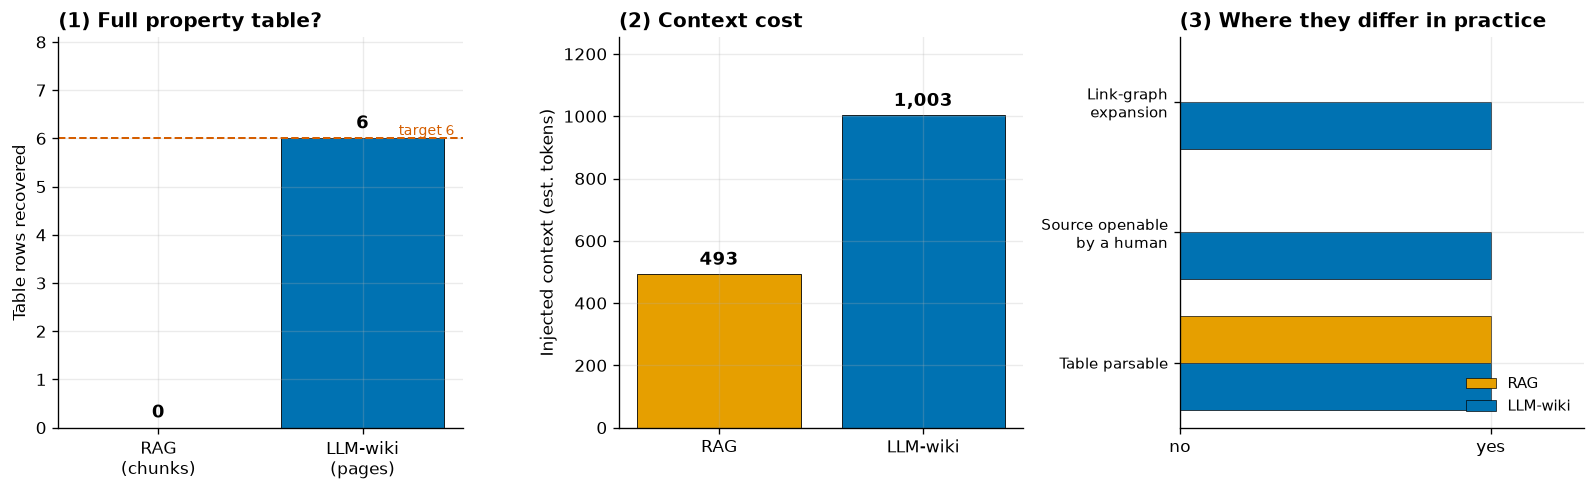

(1) 은 '검색이 정답을 통째로 물어왔나' 입니다. 청크 경계가 표를 자르면 값이 반쪽만 옵니다.
(2) 토큰이 적다고 좋은 것이 아닙니다 — (1) 을 만족한 상태에서 적어야 의미가 있습니다.
(3) 은 정확도가 아니라 '사고가 났을 때 추적 가능한가' 의 문제입니다.
※ 위키가 항상 낫다는 뜻이 아닙니다. 문서가 수만 건이면 페이지 색인만으로는 못 찾습니다 —
  그래서 다음 절의 하이브리드(위키로 좁히고 RAG로 당기기)가 실무 기본형입니다.


In [21]:
# --- 7-3b. 같은 질문, 두 방식 — 위 표의 숫자를 그림으로 ---
# 바로 위 표에 있는 값만 쓴다 (새로 계산하는 값 없음).

import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.2))

ax = axes[0]
ax.bar(["RAG\n(chunks)", "LLM-wiki\n(pages)"], [rag_rows, wiki_rows],
       color=[CB["orange"], CB["blue"]], edgecolor="black", linewidth=0.5)
ax.axhline(N_CARDS, color=CB["red"], ls="--", lw=1.2)
ax.text(1.45, N_CARDS, f"target {N_CARDS}", color=CB["red"], fontsize=8.5,
        va="bottom", ha="right")
for x, v in enumerate([rag_rows, wiki_rows]):
    ax.text(x, v + N_CARDS * 0.035, str(v), ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, N_CARDS * 1.35); ax.set_ylabel("Table rows recovered")
ax.set_title("(1) Full property table?", loc="left", fontweight="bold")

ax = axes[1]
_rt, _wt = approx_tokens(rag_context), approx_tokens(wiki_context)
ax.bar(["RAG", "LLM-wiki"], [_rt, _wt],
       color=[CB["orange"], CB["blue"]], edgecolor="black", linewidth=0.5)
for x, v in enumerate([_rt, _wt]):
    ax.text(x, v + max(_rt, _wt) * 0.03, f"{v:,}", ha="center", fontsize=10.5,
            fontweight="bold")
ax.set_ylim(0, max(_rt, _wt) * 1.25)
ax.set_ylabel("Injected context (est. tokens)")
ax.set_title("(2) Context cost", loc="left", fontweight="bold")

ax = axes[2]
_items = ["Table parsable", "Source openable\nby a human", "Link-graph\nexpansion"]
_rag_ok = [table_parsable(rag_context), False, False]
_wiki_ok = [table_parsable(wiki_context), True, bool(w_search.get("related_pages"))]
y = np.arange(len(_items)); h = 0.36
ax.barh(y + h / 2, [1 if v else 0 for v in _rag_ok], height=h, color=CB["orange"],
        edgecolor="black", linewidth=0.4, label="RAG")
ax.barh(y - h / 2, [1 if v else 0 for v in _wiki_ok], height=h, color=CB["blue"],
        edgecolor="black", linewidth=0.4, label="LLM-wiki")
ax.set_yticks(y); ax.set_yticklabels(_items, fontsize=9)
ax.set_xticks([0, 1]); ax.set_xticklabels(["no", "yes"])
ax.set_xlim(0, 1.3); ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_title("(3) Where they differ in practice", loc="left", fontweight="bold")

plt.tight_layout(); plt.show()
print("(1) 은 '검색이 정답을 통째로 물어왔나' 입니다. 청크 경계가 표를 자르면 값이 반쪽만 옵니다.")
print("(2) 토큰이 적다고 좋은 것이 아닙니다 — (1) 을 만족한 상태에서 적어야 의미가 있습니다.")
print("(3) 은 정확도가 아니라 '사고가 났을 때 추적 가능한가' 의 문제입니다.")
print("※ 위키가 항상 낫다는 뜻이 아닙니다. 문서가 수만 건이면 페이지 색인만으로는 못 찾습니다 —")
print("  그래서 다음 절의 하이브리드(위키로 좁히고 RAG로 당기기)가 실무 기본형입니다.")


### 7-4. 하이브리드 — 위키로 **스코프를 좁히고**, RAG로 **상세를 당긴다**

실전에서는 둘 중 하나를 고르는 게 아니라 **2단 검색**을 쓴다.

```
질문
 └─ 1단: search_wiki(query)              # 유한한 색인에서 "어느 영역인가" 판정 (싸다, 설명 가능)
      └─ 후보 페이지 (+ [[링크]] 이웃)
           └─ 2단: RAG 검색을 그 스코프로 제한   # 후보 페이지들의 청크만 대상
                └─ top-k 청크 + 페이지 경로를 함께 주입
                     └─ LLM은 "어느 파일의 몇 번째 줄"인지 아는 채로 답한다
```

핵심은 **1단이 근거를 파일 경로로 고정**한다는 것. 2단이 청크를 가져와도
"이 청크는 `wiki/decision_log.md` 의 9-14줄"이라는 앵커가 유지되므로 감사 가능성이 살아남는다.
스코프 축소는 정확도뿐 아니라 **비용**에도 직결된다 (검색 대상 청크 수 = 임베딩 조회량).

In [22]:
def hybrid_retrieve(query, n_pages=1, k=3, follow_links=False):
    """1단 wiki 색인으로 스코프 축소 → 2단 그 스코프 안에서만 TF-IDF 청크 검색."""
    s = search_wiki(query, k=n_pages)
    scope = [h["page"] for h in s["hits"]]
    if follow_links:                                   # [[링크]] 이웃까지 스코프 확장
        scope += [p for p in s["related_pages"] if p not in scope]
    if not scope:                                      # 색인 miss → 전체 폴백 (커버리지 한계 인정)
        scope, fell_back = _wiki_pages(), True
    else:
        fell_back = False
    idx = [i for i, c in enumerate(CHUNKS) if c["page"] in scope]
    sel, sims = _cos_scores(query, idx)
    order = sorted(range(len(sel)), key=lambda j: -sims[j])[:k]
    hits = [{**CHUNKS[sel[j]], "score": round(float(sims[j]), 3)} for j in order]
    return {"query": query, "stage1_scope": scope, "stage1_fallback": fell_back,
            "stage1_why": {h["page"]: list(h["matched_terms"])[:5] for h in s["hits"]},
            "n_chunks_total": len(CHUNKS), "n_chunks_searched": len(idx),
            "stage2_hits": hits,
            "provenance": [f"wiki/{h['page']}.md:{h['line_range'][0]}-{h['line_range'][1]}" for h in hits]}

Q2 = "제외된 화합물의 lead-like 위반 근거 수치"
for tag, kw in [("링크 미추적", dict(follow_links=False)), ("[[링크]] 이웃까지 확장", dict(follow_links=True))]:
    hy = hybrid_retrieve(Q2, n_pages=1, k=3, **kw)
    print(f"── {tag}: 스코프 {hy['stage1_scope']} → 검색 대상 청크 "
          f"{hy['n_chunks_searched']}/{hy['n_chunks_total']} "
          f"({100 * hy['n_chunks_searched'] / hy['n_chunks_total']:.0f}%)")

hy = hybrid_retrieve(Q2, n_pages=1, k=3)
print(f"\n질문: {Q2}")
print("1단 매칭 근거(설명 가능):", hy["stage1_why"])
print("\n2단 (스코프 내 TF-IDF top-3):")
for h in hy["stage2_hits"]:
    print(f"\n▶ wiki/{h['page']}.md:{h['line_range'][0]}-{h['line_range'][1]}  cos={h['score']}")
    print("\n".join("   " + l for l in h["text"].splitlines()[:6]))
print("\n최종 근거(감사 로그에 그대로 남길 값):", hy["provenance"])
print("\n※ 이 위키는 페이지가 4개뿐이라 스코프 축소 효과가 작아 보인다. "
      "페이지가 수백 개인 실제 프로젝트에서는 1단이 검색 대상을 한 자릿수 %로 줄인다.")


── 링크 미추적: 스코프 ['decision_log'] → 검색 대상 청크 9/26 (35%)
── [[링크]] 이웃까지 확장: 스코프 ['decision_log', 'compound_cards', 'target_EGFR'] → 검색 대상 청크 22/26 (85%)

질문: 제외된 화합물의 lead-like 위반 근거 수치
1단 매칭 근거(설명 가능): {'decision_log': ['lead-like', '근거', '수치', '위반', '제외된']}

2단 (스코프 내 TF-IDF top-3):

▶ wiki/decision_log.md:9-14  cos=0.23
   - Tier 1 게이트: Lipinski Ro5(위반 ≤1) AND Veber(RotB≤10, TPSA≤140)
   - Tier 2 쇼트리스트: Tier 1 통과분 중 MW≤350 AND logP≤3.5 (lead-like)
   - **결과: 최종 쇼트리스트 2건 / 제외 4건 (Tier 1 0건, Tier 2 4건)**
   
   ## 제외된 후보 (실제로 규칙에 걸린 것만)
   | ChEMBL ID | 걸린 게이트 | 제외 사유 | 근거 수치 (RDKit 실계산) |

▶ wiki/decision_log.md:13-18  cos=0.213
   ## 제외된 후보 (실제로 규칙에 걸린 것만)
   | ChEMBL ID | 걸린 게이트 | 제외 사유 | 근거 수치 (RDKit 실계산) |
   |---|---|---|---|
   | CHEMBL68920 | Tier 2 | lead-like 미달 MW<=350,logP<=3.5 | MW=383.8, logP=4.45, TPSA=82.7, HBD=3, HBA=4, RotB=3 |
   | CHEMBL69960 | Tier 2 | lead-like 미달 MW<=350,logP<=3.5 | MW=482.9, logP=3.61, TPSA=112.2, HBD=3, HBA=6, RotB=4 |
   | CHEMBL137635 | Tier 2 

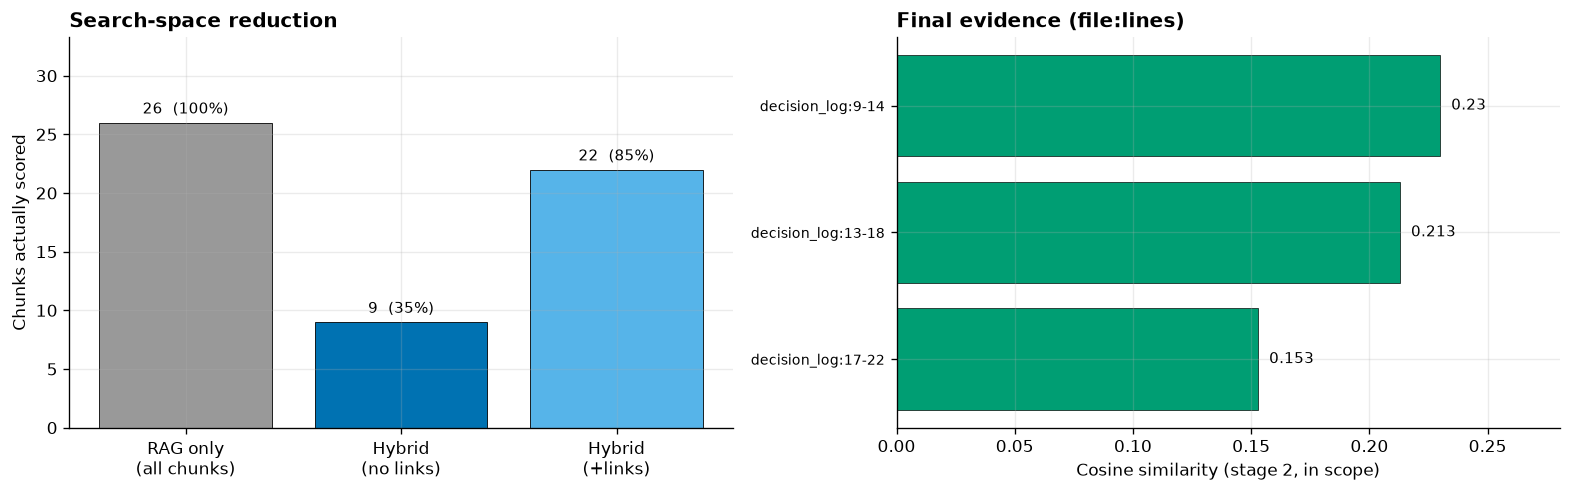

질문: 제외된 화합물의 lead-like 위반 근거 수치
위키 페이지가 4개뿐이라 축소 효과가 작아 보입니다.
페이지가 수백 개인 실제 프로젝트에서는 1단이 검색 대상을 한 자릿수 %로 줄입니다 —
그만큼 오탐(엉뚱한 문서의 청크가 top-k 를 차지하는 일)이 줄어듭니다.
오른쪽 y축 라벨이 곧 감사 로그에 남길 근거(파일:줄번호)입니다.


In [23]:
# --- 7-4b. 하이브리드가 검색 대상을 얼마나 줄였나 ---
# 1단(위키 색인)이 스코프를 좁힌 정도를 세 방식으로 비교한다.

_h_nolink = hybrid_retrieve(Q2, n_pages=1, k=3, follow_links=False)
_h_link = hybrid_retrieve(Q2, n_pages=1, k=3, follow_links=True)
_modes = [("RAG only\n(all chunks)", len(CHUNKS)),
          ("Hybrid\n(no links)", _h_nolink["n_chunks_searched"]),
          ("Hybrid\n(+links)", _h_link["n_chunks_searched"])]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.2))

ax = axes[0]
_names = [m[0] for m in _modes]; _vals = [m[1] for m in _modes]
ax.bar(_names, _vals, color=[CB["grey"], CB["blue"], CB["sky"]],
       edgecolor="black", linewidth=0.5)
for x, v in enumerate(_vals):
    ax.text(x, v + len(CHUNKS) * 0.03, f"{v}  ({100 * v / len(CHUNKS):.0f}%)",
            ha="center", fontsize=9)
ax.set_ylim(0, len(CHUNKS) * 1.28); ax.set_ylabel("Chunks actually scored")
ax.set_title("Search-space reduction", loc="left", fontweight="bold")

ax = axes[1]
_hy = _h_nolink
if not _hy["stage2_hits"]:
    _nodata(ax, "stage-2 returned nothing")
else:
    _lab = [f"{h['page']}:{h['line_range'][0]}-{h['line_range'][1]}"
            for h in _hy["stage2_hits"]][::-1]
    _sc = [h["score"] for h in _hy["stage2_hits"]][::-1]
    _mx = max(_sc) or 1
    ax.barh(_lab, _sc, color=CB["green"], edgecolor="black", linewidth=0.4)
    for y, v in enumerate(_sc):
        ax.text(v + _mx * 0.02, y, f"{v}", va="center", fontsize=9)
    ax.set_xlim(0, _mx * 1.22); ax.set_xlabel("Cosine similarity (stage 2, in scope)")
    ax.tick_params(axis="y", labelsize=8.5)
    ax.set_title("Final evidence (file:lines)", loc="left", fontweight="bold")

plt.tight_layout(); plt.show()
print(f"질문: {Q2}")
print(f"위키 페이지가 {len(_wiki_pages())}개뿐이라 축소 효과가 작아 보입니다.")
print("페이지가 수백 개인 실제 프로젝트에서는 1단이 검색 대상을 한 자릿수 %로 줄입니다 —")
print("그만큼 오탐(엉뚱한 문서의 청크가 top-k 를 차지하는 일)이 줄어듭니다.")
print("오른쪽 y축 라벨이 곧 감사 로그에 남길 근거(파일:줄번호)입니다.")


## 8. 한계와 주의

- **환각(hallucination):** LLM은 그럴듯한 가짜 PMID/ChEMBL ID/IC50를 만들어낼 수 있다.
  이 노트북은 그래서 **수치·식별자를 전부 도구(실 API/RDKit)에서만** 가져오고, 보고서 조립도 트레이스 값만 쓴다.
  실전에서도 "LLM이 말한 수치"는 **항상 도구로 재검증** 해야 한다.
- **규칙기반 ADMET의 한계:** `admet_flags`는 Lipinski/Veber/lead-like **규칙 필터**다. 실제 흡수·분포·대사·배설·독성은
  이 규칙으로 알 수 없다 — 전용 ML 모델(예: ADMET-AI/TxGemma류)이나 실험이 필요하다. "예측"이라 부르지 말 것.
- **pChEMBL/활성값:** 서로 다른 어세이·조건의 집계라 화합물 간 직접 비교에 주의. 단위·relation(`=`/`>`) 확인 필수.
- **검증(verification) 필요:** 에이전트 산출물은 **가설**이다. 신약 발견이 아니라 알려진 화학공간의 정리·선별 시연이다.
- **재현성:** 네트워크 상태·DB 업데이트로 반환 화합물이 달라질 수 있다. 감사 로그와 timestamp로 추적한다.

### 8-1. 기억(memory) 방식별 한계 — LLM-wiki vs RAG

**LLM-wiki 쪽 한계**
- **커버리지 한계:** 위키에 없는 건 못 찾는다. RAG처럼 "일단 다 넣고 검색"이 안 되므로
  **무엇을 페이지로 만들지 사람이 정해야** 한다. 색인 밖 질문은 조용히 빈손으로 돌아온다
  (위 `hybrid_retrieve` 가 miss 시 전체 폴백을 두는 이유).
- **큐레이션 비용:** 페이지가 늘면 중복·모순·낡은 내용이 쌓인다. 갱신 **오너십**이 없으면 위키는 썩는다.
  이 노트북처럼 **매 실행마다 실데이터로 재생성**하거나, 갱신 규칙("결정이 바뀌면 `decision_log.md`에 append")을
  강제해야 한다.
- **규모 한계:** 수만 페이지를 넘어가면 키워드 색인 순회가 무너진다 — 그 지점부터는 RAG가 필요하다.
- **키워드 매칭의 취약성:** 위 `search_wiki` 는 어휘가 겹쳐야 찾는다("제외" vs "exclusion").
  동의어 사전이나 임베딩 보조가 없으면 놓친다.

**RAG 쪽 한계**
- **청크 경계(chunk boundary):** 고정 크기로 자르면 표·코드·목록이 중간에서 끊긴다.
  7-3의 비교에서 본 것처럼 **표 헤더와 데이터 행이 다른 청크로 흩어지면** LLM은 그 표를 표로 못 읽는다.
- **lost-in-the-middle:** 긴 컨텍스트의 **중간**에 놓인 근거는 앞/뒤보다 활용률이 떨어진다는 실증 결과가 있다.
  top-k를 무작정 늘리는 게 답이 아니다.
- **근거 추적의 간접성:** "청크 #47"은 원문 매핑 없이는 사람이 열어볼 수 없고,
  인덱스를 재빌드하면 id가 바뀌어 **과거 감사 기록이 깨질 수** 있다.
- **갱신 지연(stale index):** 문서가 바뀌어도 재임베딩 전까지 옛 내용을 반환한다.
- **검색 품질 ≠ 답변 품질:** 관련 청크를 잘 찾아와도 LLM이 그 안의 수치를 잘못 읽으면 그대로 틀린다.
  **수치는 여전히 도구로 재검증**해야 한다 (이 노트북의 무-날조 원칙).

> **한 줄 요약:** RAG는 *많이* 기억하고, wiki는 *정확히* 기억한다.
> 규제·감사가 걸린 의사결정 기록에는 wiki 계열(파일 경로 근거)이, 수십만 편의 문헌 탐색에는 RAG가 맞다.
> 실전은 7-4의 하이브리드다.

## 9. 다음 실습

- `pde5_harness/` — 같은 원리를 Claude Code **하네스**(CLAUDE.md 규약 + 검증 훅)로 구현한 버전.
  자연어 지시 하나로 PLAN→검증 게이트→보고서까지 자율 실행한다. (실습 가이드: `pde5_harness_실습가이드.md`)
- `t050_simple-local-rag.ipynb` (6일차) — 여기서 TF-IDF로 축소해 보여준 RAG를,
  **임베딩 기반 검색 파이프라인**으로 처음부터 제대로 만든다. "검색을 잘 만드는 법" 쪽 짝이다.
- `t042_molt5.ipynb` (6일차) — 도구 없이 **모델 자체**가 분자와 자연어를 번역하는 경우.
  세대별로 무엇이 되고 무엇이 안 되는지 기계적 지표로 비교한다.
- 다중 에이전트(co-scientist): 가설 생성/비평/랭킹을 여러 에이전트로 분업 (2026 트렌드).
- 생성된 `wiki/` 를 git 저장소로 만들어 **결정 이력을 커밋**해 보기 — 에이전트의 기억이 곧 감사 로그가 된다.

---
*무-날조 원칙 준수: 이 노트북의 모든 값은 실제 API 응답 또는 RDKit 실계산이다.*